# TCC — Análise Comparativa e Estatística

### Mitigação de Débito Técnico Estrutural — Spring PetClinic REST

Este notebook consolida a análise quantitativa do estudo de caso (Capítulo 5): compara três
versões (_branches_) da aplicação Spring PetClinic REST — **Baseline** (fork original, sem
intervenções), **Baseline Degradada** (anomalias estruturais injetadas propositalmente) e
**Pós-Refatoração** (anomalias corrigidas) — combinando:

- **Métricas estáticas** (PMD, ArchUnit) → débito técnico estrutural (ISO/IEC 25010 — Manutenibilidade);
- **Métricas dinâmicas** (K6, 5 execuções por cenário) → latência (p90/p95/p99), taxa de erros,
  throughput e saturação (ISO/IEC 25010 — Eficiência de Desempenho e Confiabilidade);
- **Tratamento estatístico** (média, desvio padrão, CV%, Mann-Whitney U, Cliff's Delta) para
  validar se as diferenças observadas são estatisticamente significativas e materialmente relevantes.

O notebook não redige o Capítulo 5 — ele produz as tabelas, figuras e números "quentes" que
alimentarão a redação.


### ⚠️ Fora do escopo deste notebook (decisão consciente)

- **Profundidade de pilha / _spans_ (`@Observed`)**: conforme observado o Prometheus descarta o rastreamento de chamadas
  internas — isso exigiria um backend de _tracing_ (Tempo/Jaeger) que não está entre os dados
  fornecidos. A tabela de profundidade de spans já documentada em `01_Variaveis_e_Metricas.md §3.3`
  deve ser usada como está (qualitativa/arquitetural), sem tentar derivá-la deste conjunto de dados.
- **Fatores de validade externa** (carga do host, _thermal throttling_, variação do _scheduler_) —
  documentados em `06_Isolamento_e_Reprodutibilidade.md §7` — não são calculáveis a partir dos
  dados e devem ser citados como limitação na redação do capítulo, não gerados aqui.

In [1]:
# --- Bibliotecas e configuração global -------------------------------------
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Pasta de saída para figuras (.png, 300 DPI) e planilhas (.xlsx)
OUTPUT_DIR = Path("resultados_estatisticos")
OUTPUT_DIR.mkdir(exist_ok=True)

def legenda(texto: str):
    """Exibe uma legenda/descrição em itálico logo abaixo de uma tabela ou figura,
    no padrão 'Tabela X — descrição' usado no corpo do TCC."""
    display(Markdown(f"<div style='font-size:0.85em;color:#555;margin-top:4px'><i>{texto}</i></div>"))

## 1. Configuração dos Cenários (Branches) e Localização dos Dados

Cada cenário corresponde a uma _branch_ Git do experimento (hierarquia definida em
`04_Pos_Refatoracao_e_Padroes.md`). A pasta `data/` é esperada com a seguinte estrutura:

```
data/
├── k6/       # CSVs e JSONs de saída do K6 (5 execuções por cenário)
├── pmd/      # CSVs de violações do PMD
└── archunit/ # Logs .txt da suíte ValidacaoArquiteturalTest
```

Ajuste `BASE_DIR` abaixo se a estrutura local for diferente.


In [2]:
BASE_DIR = Path("data")
N_RUNS_ESPERADO = 5  # protocolo de 5 rodadas independentes (06_Isolamento_e_Reprodutibilidade.md)

# Ordem lógica usada em todo o notebook: Baseline -> Baseline Degradada -> Pós-Refatoração
SCENARIOS = {
    "baseline": {
        "label": "Baseline",
        "color": "#4dabf7",
        "k6_csv_glob": "k6/k6-metrics-refactoring-metrics_run_*.csv",
        "k6_json_glob": "k6/k6-summary-refactoring-metrics_run_*.json",
        "pmd_csv": "pmd/pmd-refactoring-metrics.csv",
        "archunit_txt": "archunit/refactoring-metrics-archunit.txt",
    },
    "degradada": {
        "label": "Baseline Degradada",
        "color": "#ff6b6b",
        "k6_csv_glob": "k6/k6-metrics-refactoring-metrics-intentional-code-smells_run_*.csv",
        "k6_json_glob": "k6/k6-summary-refactoring-metrics-intentional-code-smells_run_*.json",
        "pmd_csv": "pmd/pmd-refactoring-metrics-intentional-code-smells.csv",
        "archunit_txt": "archunit/refactoring-metrics-intentional-code-smells-archunit.txt",
    },
    "pos_refatoracao": {
        "label": "Pós-Refatoração",
        "color": "#51cf66",
        "k6_csv_glob": "k6/k6-metrics-refactoring-metrics-pos-refactoring_run_*.csv",
        "k6_json_glob": "k6/k6-summary-refactoring-metrics-pos-refactoring_run_*.json",
        "pmd_csv": "pmd/pmd-refactoring-metrics-pos-refactoring.csv",
        "archunit_txt": "archunit/refactoring-metrics-pos-refactoring-archunit.txt",
    },
}

# Paleta consistente (reutilizada em todos os gráficos do notebook)
PALETA = {cfg["label"]: cfg["color"] for cfg in SCENARIOS.values()}
ORDEM_CENARIOS = [cfg["label"] for cfg in SCENARIOS.values()]

def resolve_paths(base_dir: Path, scenario_cfg: dict) -> dict:
    return {
        "k6_csv_files": sorted(base_dir.glob(scenario_cfg["k6_csv_glob"])),
        "k6_json_files": sorted(base_dir.glob(scenario_cfg["k6_json_glob"])),
        "pmd_csv": base_dir / scenario_cfg["pmd_csv"],
        "archunit_txt": base_dir / scenario_cfg["archunit_txt"],
    }

RESOLVED_PATHS = {name: resolve_paths(BASE_DIR, cfg) for name, cfg in SCENARIOS.items()}

# --- Sanity check: confirma que todas as 5 rodadas de cada cenário foram encontradas -------
print(f"{'Cenário':<20} {'CSVs K6':>10} {'JSONs K6':>10} {'PMD':>6} {'ArchUnit':>10}")
for nome, cfg in SCENARIOS.items():
    p = RESOLVED_PATHS[nome]
    n_csv, n_json = len(p["k6_csv_files"]), len(p["k6_json_files"])
    aviso = "  ⚠️ esperado 5" if (n_csv != N_RUNS_ESPERADO or n_json != N_RUNS_ESPERADO) else ""
    print(f"{cfg['label']:<20} {n_csv:>10} {n_json:>10} {p['pmd_csv'].exists()!s:>6} {p['archunit_txt'].exists()!s:>10}{aviso}")

Cenário                 CSVs K6   JSONs K6    PMD   ArchUnit
Baseline                      5          5   True       True
Baseline Degradada            5          5   True       True
Pós-Refatoração               5          5   True       True


## 2. Ingestão dos Dados Brutos do K6 (CSV)

Cada CSV bruto contém **uma linha por ponto de dado** (todas as métricas, todas as fases,
`warmup` + `steady_state`), o que resulta em arquivos grandes (~100 MB por execução). A leitura é
feita em blocos (`chunksize`) para controlar o uso de memória, mantendo apenas:

1. As métricas de interesse (`http_req_duration`, `http_reqs`, `http_req_failed`);
2. Apenas a fase **`steady_state`** — a fase `warmup` é descartada aqui (ver nota metodológica
   na introdução);
3. Apenas grupos de endpoint reais — o grupo `::setup` (checagem de saúde pré-teste) é descartado.


In [3]:
# Métricas do K6 relevantes para latência, contagem de requisições e falhas
METRICAS_INTERESSE = {"http_req_duration", "http_reqs", "http_req_failed"}

# Colunas efetivamente usadas (lidas seletivamente para reduzir memória/tempo de parsing)
K6_CSV_USECOLS = ["metric_name", "timestamp", "metric_value", "name", "group", "scenario"]
K6_CSV_DTYPES = {"metric_name": "category", "name": "category", "group": "category", "scenario": "category"}


def carregar_k6_csv_run(filepath: Path, run_number: int, chunksize: int = 500_000) -> pd.DataFrame:
    """Lê um CSV bruto do K6 em blocos, mantendo somente as métricas de interesse
    e apenas a fase de regime estável (scenario == 'steady_state')."""
    if not filepath or not Path(filepath).exists():
        return pd.DataFrame()

    chunks_filtrados = []
    try:
        leitor = pd.read_csv(
            filepath,
            usecols=lambda c: c in K6_CSV_USECOLS,
            dtype={k: v for k, v in K6_CSV_DTYPES.items() if k in K6_CSV_USECOLS},
            chunksize=chunksize,
            low_memory=False,
            on_bad_lines="skip",
        )
        for chunk in leitor:
            if "metric_name" not in chunk.columns:
                continue
            chunk = chunk[chunk["metric_name"].isin(METRICAS_INTERESSE)]
            # Exclui a fase de warm-up: só a fase 'steady_state' representa o regime avaliado
            if "scenario" in chunk.columns:
                chunk = chunk[chunk["scenario"] == "steady_state"]
            # Exclui o grupo de checagem de saúde pré-teste
            if "group" in chunk.columns:
                chunk = chunk[chunk["group"].astype(str) != "::setup"]
            if not chunk.empty:
                chunks_filtrados.append(chunk)
    except Exception as exc:
        print(f"  [aviso] falha ao ler {filepath.name}: {exc}")
        return pd.DataFrame()

    if not chunks_filtrados:
        return pd.DataFrame()

    df = pd.concat(chunks_filtrados, ignore_index=True)
    df["run"] = run_number
    df["metric_value"] = pd.to_numeric(df["metric_value"], errors="coerce")
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.drop(columns=["scenario"])  # já cumpriu seu papel de filtro
    return df.dropna(subset=["metric_value", "timestamp"])


def consolidar_k6_csv_cenario(csv_files: list) -> pd.DataFrame:
    """Concatena as N execuções de um cenário em um único DataFrame, numerando cada run."""
    dfs = []
    for i, fp in enumerate(csv_files, start=1):
        run_match = re.search(r"run_(\d+)", fp.name)
        run_number = int(run_match.group(1)) if run_match else i
        df_run = carregar_k6_csv_run(fp, run_number)
        if not df_run.empty:
            dfs.append(df_run)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


dados_k6 = {}
for nome_cenario, cfg in SCENARIOS.items():
    dados_k6[nome_cenario] = consolidar_k6_csv_cenario(RESOLVED_PATHS[nome_cenario]["k6_csv_files"])
    n_linhas = len(dados_k6[nome_cenario])
    n_runs_lidos = dados_k6[nome_cenario]["run"].nunique() if n_linhas else 0
    print(f"{cfg['label']:<20} → {n_linhas:>10,} pontos de dado (steady_state) em {n_runs_lidos} execuções")

Baseline             →    600,564 pontos de dado (steady_state) em 5 execuções
Baseline Degradada   →    281,088 pontos de dado (steady_state) em 5 execuções
Pós-Refatoração      →    714,939 pontos de dado (steady_state) em 5 execuções


### 2.1 Ingestão dos Sumários JSON (`summary.json`)

O `summary.json` de cada execução já traz, pré-computados: `meta` (executor, taxa alvo),
`resumo_por_endpoint` (latência e erro por endpoint), `global` (taxa de erro global, iterações
descartadas, contadores de escrita bem-sucedida) e `threshold_status`. Diferente da versão
anterior — que reimplementava a extração navegando por `raw.metrics` com nomes de métricas
"mágicos" —, esta versão lê diretamente esses blocos já estruturados, o que é mais simples e
menos frágil a mudanças no script K6.

**Uso neste notebook:** o JSON é a fonte para _throughput_, contadores de sucesso e
`dropped_iterations` (não disponíveis de forma direta no CSV). Os percentis de latência
(p90/p95/p99) usados nas seções seguintes vêm do CSV filtrado (Seção 2), por ser auditável e
imune à ambiguidade da tag `phase:test` no `handleSummary` (ver nota metodológica).


In [4]:
# Mapa de endpoints -> rótulo amigável (mesma nomenclatura usada no CSV, sem "::")
ENDPOINTS_LABEL = {
    "GET /owners": "GET /owners",
    "POST /owners": "POST /owners",
    "GET /owners/{ownerId}": "GET /owners/{id}",
    "POST /owners/{ownerId}/pets": "POST /owners/{id}/pets",
    "POST /owners/{ownerId}/pets/{petId}/visits": "POST /owners/{id}/pets/{pid}/visits",
    "GET /vets": "GET /vets",
}


def carregar_k6_json_run(filepath: Path) -> dict:
    with open(filepath, "r", encoding="utf-8") as f:
        return json.load(f)


registros_execucao = []
for cenario_key, cfg in SCENARIOS.items():
    for fp in RESOLVED_PATHS[cenario_key]["k6_json_files"]:
        run_match = re.search(r"run_(\d+)", fp.name)
        run_number = int(run_match.group(1)) if run_match else 0

        summary = carregar_k6_json_run(fp)
        meta = summary.get("meta", {})
        glob = summary.get("global", {})
        resumo = summary.get("resumo_por_endpoint", {})

        # raw.metrics ainda é necessário para taxas globais (http_reqs.rate, iterations.rate etc.)
        raw_metrics = summary.get("raw", {}).get("metrics", {})

        def taxa(metric_name):
            return raw_metrics.get(metric_name, {}).get("values", {}).get("rate", np.nan)

        registro = {
            "cenario": cenario_key,
            "cenario_label": cfg["label"],
            "run": run_number,
            "executor": meta.get("executor"),
            "taxa_alvo_reqs_s": meta.get("rate_por_segundo"),
            "duracao_min": summary.get("raw", {}).get("state", {}).get("testRunDurationMs", 0) / 1000 / 60,
            "throughput_http_reqs_s": taxa("http_reqs"),
            "throughput_iteracoes_s": taxa("iterations"),
            "taxa_erro_global": glob.get("taxa_erro_global", {}).get("rate", np.nan),
            "dropped_iterations": glob.get("dropped_iterations", {}).get("count", 0),
            "owners_criados_sucesso": glob.get("counters", {}).get("owners_criados_com_sucesso", np.nan),
            "pets_criados_sucesso": glob.get("counters", {}).get("pets_criados_com_sucesso", np.nan),
            "visits_criadas_sucesso": glob.get("counters", {}).get("visits_criadas_com_sucesso", np.nan),
        }

        # p95 por endpoint (cruzamento/validação — fonte oficial é o CSV, Seção 3)
        for ep_full, ep_label in ENDPOINTS_LABEL.items():
            lat = resumo.get(ep_full, {}).get("latencia_ms", {})
            registro[f"p95_json_{ep_label}"] = lat.get("p95", np.nan)

        registros_execucao.append(registro)

df_execucoes = pd.DataFrame(registros_execucao)
print(f"Sumários JSON carregados: {len(df_execucoes)} execuções "
      f"({df_execucoes['cenario'].nunique()} cenários)")

Sumários JSON carregados: 15 execuções (3 cenários)


## 3. Visão Geral por Execução (Run) — Percentis a partir do CSV

Tabela por rodada com o volume de requisições e a latência global (`http_req_duration`, em
milissegundos) já filtrada para o regime estável. É a fonte oficial de p90/p95/p99 usada no
restante do notebook.


In [5]:
def metricas_por_run(dados_k6: dict) -> pd.DataFrame:
    """Calcula min/média/mediana/p90/p95/p99/max de latência global por execução (run)."""
    linhas = []
    for nome_cenario, df in dados_k6.items():
        if df.empty:
            continue
        df_lat = df[df["metric_name"] == "http_req_duration"]
        if df_lat.empty:
            continue

        for run, serie in df_lat["metric_value"].groupby(df_lat["run"]):
            linhas.append({
                "cenario": SCENARIOS[nome_cenario]["label"],
                "run": run,
                "n_reqs": len(serie),
                "min_ms": serie.min(),
                "media_ms": serie.mean(),
                "mediana_ms": serie.median(),
                "p90_ms": serie.quantile(0.90),
                "p95_ms": serie.quantile(0.95),
                "p99_ms": serie.quantile(0.99),
                "max_ms": serie.max(),
            })
    return pd.DataFrame(linhas)


df_runs = metricas_por_run(dados_k6)

for cenario in ORDEM_CENARIOS:
    df_sub = df_runs[df_runs["cenario"] == cenario]
    if df_sub.empty:
        continue
    display(Markdown(f"#### {cenario} — latência global por execução (ms, fase *steady_state*)"))
    tabela = df_sub.drop(columns=["cenario"]).sort_values("run").set_index("run")
    display(tabela.style.format("{:,.2f}").format({"n_reqs": "{:,.0f}"}))

legenda("Tabela 3.x — Latência global (todas as requisições, todos os endpoints) por execução "
        "e cenário, calculada a partir do CSV bruto do K6 filtrado para a fase steady_state. "
        "p95/p99 em milissegundos.")

#### Baseline — latência global por execução (ms, fase *steady_state*)

,n_reqs,min_ms,media_ms,mediana_ms,p90_ms,p95_ms,p99_ms,max_ms
run,,,,,,,,
1,"41,187",0.755761,4715.642724,4186.179898,9984.146233,12228.024759,16904.727507,33479.645412
2,"39,592",0.781614,4883.711976,4517.907042,10030.985873,12213.132134,17310.519055,33977.759107
3,"40,034",0.730783,4865.132592,4621.672135,9895.902311,12029.488915,16752.713664,33088.931678
4,"39,602",0.709850,4911.547743,4594.239577,9921.277307,12203.839080,16940.533978,35293.509153
5,"39,773",0.744340,4849.517592,4532.096381,9900.503092,12239.199507,17256.012970,39370.508468


#### Baseline Degradada — latência global por execução (ms, fase *steady_state*)

,n_reqs,min_ms,media_ms,mediana_ms,p90_ms,p95_ms,p99_ms,max_ms
run,,,,,,,,
1,"19,286",0.892191,10579.370342,3440.790756,41460.956604,60000.408548,60001.190242,60010.323393
2,"18,520",0.913853,11211.501829,3791.943648,43130.341624,60000.517931,60001.160501,60010.544615
3,"18,904",0.920987,10458.908242,2564.302190,44690.138082,60000.439414,60001.167845,60011.329492
4,"18,634",0.861778,10977.733992,3507.134751,39966.638385,60000.435401,60001.161258,60003.544158
5,"18,352",1.037955,11121.754087,3950.633943,41718.695415,60000.537753,60001.180974,60003.383164


#### Pós-Refatoração — latência global por execução (ms, fase *steady_state*)

,n_reqs,min_ms,media_ms,mediana_ms,p90_ms,p95_ms,p99_ms,max_ms
run,,,,,,,,
1,"48,140",0.452901,3487.641056,1882.074753,9644.546812,12251.879393,17666.323820,34693.855574
2,"47,246",0.467403,3508.568764,1933.874289,9616.071297,12097.267900,17457.751314,34429.662907
3,"47,690",0.474243,3589.836691,2088.447286,9577.796202,11912.570733,17139.130265,35909.323994
4,"47,547",0.388514,3670.208757,2211.080794,9595.749973,12180.044126,17278.134632,35011.781773
5,"47,690",0.512630,3594.462743,2105.177346,9558.482637,11985.924493,17379.765441,34283.321196


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 3.x — Latência global (todas as requisições, todos os endpoints) por execução e cenário, calculada a partir do CSV bruto do K6 filtrado para a fase steady_state. p95/p99 em milissegundos.</i></div>

### 3.1 Cruzamento com o `summary.json` — Throughput, Erros e Saturação

Enquanto a Seção 3 usa o CSV para latência (fonte auditável), esta seção usa o JSON para as
métricas que só ele expõe de forma direta: _throughput_ (req/s), taxa de erro global e,
principalmente, `dropped_iterations` — o indicador de **saturação** definido como variável
dependente em `01_Variaveis_e_Metricas.md` e cuja interpretação está detalhada em
`02_Instrumentacao_e_Coleta.md §7`:

| `dropped_iterations`             | Interpretação                                                             |
| -------------------------------- | ------------------------------------------------------------------------- |
| 0                                | Aplicação honrou as 26 it/s durante todo o teste — saudável               |
| > 0, início do teste             | `preAllocatedVUs` insuficiente (ajuste de configuração, não da branch)    |
| > 0, crescente ao longo do teste | Degradação progressiva (ex.: volume de dados, _memory leak_)              |
| > 0, constante e alto            | Aplicação **não sustenta** 26 it/s — limitação real da branch, documentar |


In [6]:
colunas_execucao = [
    "run", "throughput_http_reqs_s", "throughput_iteracoes_s",
    "taxa_erro_global", "dropped_iterations",
    "owners_criados_sucesso", "pets_criados_sucesso", "visits_criadas_sucesso",
]

for cenario_key, cfg in SCENARIOS.items():
    df_sub = df_execucoes[df_execucoes["cenario"] == cenario_key].copy()
    if df_sub.empty:
        continue
    display(Markdown(f"#### {cfg['label']} — throughput, erros e saturação por execução"))
    tabela = df_sub[colunas_execucao].sort_values("run").set_index("run")
    tabela.loc["Média"] = tabela.mean()
    styled = tabela.style.format({
        "throughput_http_reqs_s": "{:,.2f}",
        "throughput_iteracoes_s": "{:,.2f}",
        "taxa_erro_global": "{:.4f}",
        "dropped_iterations": "{:,.0f}",
        "owners_criados_sucesso": "{:,.0f}",
        "pets_criados_sucesso": "{:,.0f}",
        "visits_criadas_sucesso": "{:,.0f}",
    })
    display(styled)

legenda("Tabela 3.1.x — Vazão (req/s e iterações/s), taxa de erro global (fração, 4 casas "
        "decimais) e contagem de iterações descartadas (dropped_iterations, indicador de "
        "saturação) por execução, extraídos do summary.json.")

#### Baseline — throughput, erros e saturação por execução

,throughput_http_reqs_s,throughput_iteracoes_s,taxa_erro_global,dropped_iterations,owners_criados_sucesso,pets_criados_sucesso,visits_criadas_sucesso
run,,,,,,,
1,56.56,7.91,0.0000,"12,753","6,257","6,201","6,141"
2,54.48,7.61,0.0000,"12,917","6,041","5,944","5,908"
3,55.07,7.71,0.0000,"12,927","6,082","6,032","5,986"
4,54.49,7.62,0.0000,"12,943","6,042","5,953","5,916"
5,54.72,7.65,0.0000,"12,902","6,058","5,984","5,940"
Média,55.07,7.70,0.0000,"12,888","6,096","6,023","5,978"


#### Baseline Degradada — throughput, erros e saturação por execução

,throughput_http_reqs_s,throughput_iteracoes_s,taxa_erro_global,dropped_iterations,owners_criados_sucesso,pets_criados_sucesso,visits_criadas_sucesso
run,,,,,,,
1,27.92,3.95,0.0576,"15,765","3,130","3,019","3,019"
2,26.92,3.77,0.0659,"15,840","2,965","2,946","2,882"
3,27.41,3.79,0.0596,"15,821","3,013","3,012","3,012"
4,27.07,3.78,0.0602,"15,897","2,969","2,969","2,969"
5,26.69,3.64,0.0658,"15,934","3,008","3,005","2,820"
Média,27.20,3.78,0.0618,"15,851","3,017","2,990","2,940"


#### Pós-Refatoração — throughput, erros e saturação por execução

,throughput_http_reqs_s,throughput_iteracoes_s,taxa_erro_global,dropped_iterations,owners_criados_sucesso,pets_criados_sucesso,visits_criadas_sucesso
run,,,,,,,
1,65.64,9.31,0.0000,"11,814","7,185","7,182","7,177"
2,64.46,9.07,0.0000,"11,845","7,118","7,043","7,001"
3,65.01,9.24,0.0000,"11,875","7,114","7,112","7,110"
4,64.83,9.25,0.0000,"11,906","7,092","7,091","7,090"
5,65.03,9.25,0.0000,"11,878","7,114","7,112","7,112"
Média,64.99,9.22,0.0000,"11,864","7,125","7,108","7,098"


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 3.1.x — Vazão (req/s e iterações/s), taxa de erro global (fração, 4 casas decimais) e contagem de iterações descartadas (dropped_iterations, indicador de saturação) por execução, extraídos do summary.json.</i></div>

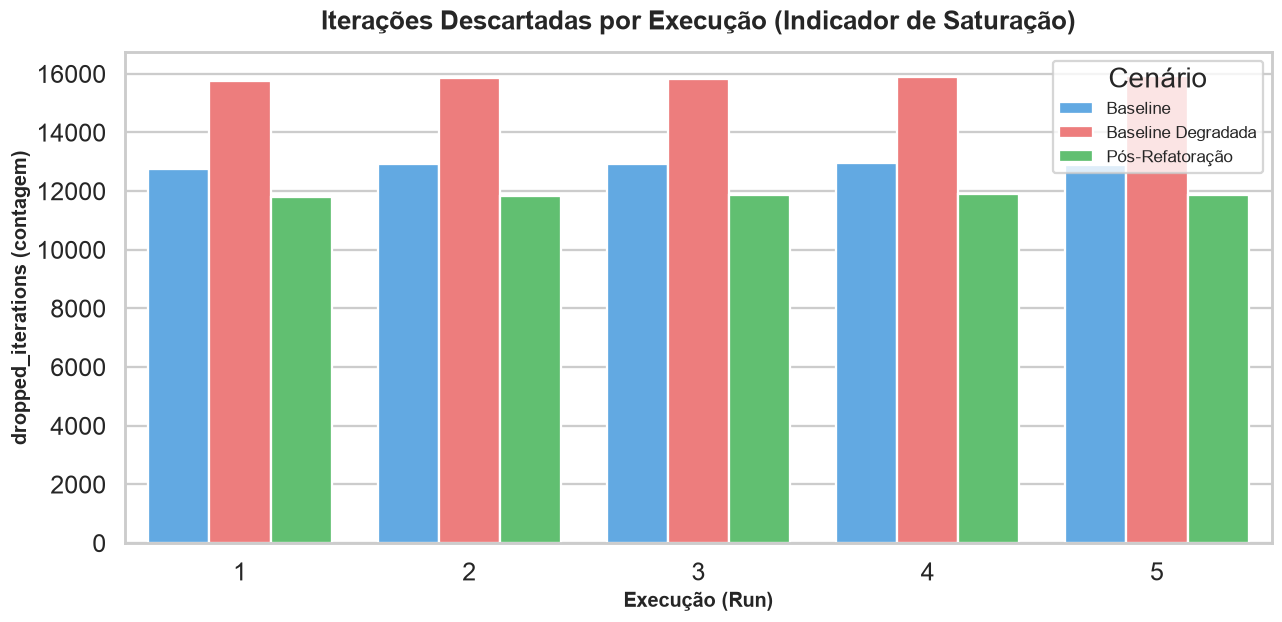

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 3.1 — Iterações descartadas pelo K6 (dropped_iterations) por execução e cenário. Valores consistentemente altos indicam que a branch não sustentou a taxa de disparo de 26 it/s (saturação real da aplicação sob o executor open-loop), e não um artefato de configuração do teste.</i></div>

In [7]:
# Gráfico de barras: iterações descartadas por execução e cenário — visão rápida de saturação
plt.figure(figsize=(12, 6))
df_sat = df_execucoes.copy()
df_sat["cenario_label"] = pd.Categorical(df_sat["cenario_label"], categories=ORDEM_CENARIOS, ordered=True)
ax = sns.barplot(
    data=df_sat, x="run", y="dropped_iterations", hue="cenario_label",
    palette=PALETA, order=sorted(df_sat["run"].unique())
)
plt.title("Iterações Descartadas por Execução (Indicador de Saturação)", fontsize=17, pad=15)
plt.xlabel("Execução (Run)", fontsize=13, fontweight="bold")
plt.ylabel("dropped_iterations (contagem)", fontsize=13, fontweight="bold")
plt.legend(title="Cenário", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "saturacao_dropped_iterations.png", dpi=300)
plt.show()

legenda("Figura 3.1 — Iterações descartadas pelo K6 (dropped_iterations) por execução e "
        "cenário. Valores consistentemente altos indicam que a branch não sustentou a taxa "
        "de disparo de 26 it/s (saturação real da aplicação sob o executor open-loop), e "
        "não um artefato de configuração do teste.")

In [8]:
# Endpoints avaliados nas visualizações de latência (rótulo do CSV -> nome amigável)
ENDPOINTS_VALIDOS = {
    "::GET /owners": "GET /owners",
    "::GET /owners/{ownerId}": "GET /owners/{id}",
    "::GET /vets": "GET /vets",
    "::POST /owners": "POST /owners",
    "::POST /owners/{ownerId}/pets": "POST /owners/{id}/pets",
    "::POST /owners/{ownerId}/pets/{petId}/visits": "POST /owners/{id}/pets/{pid}/visits",
}


def montar_df_latencia_por_endpoint(dados_k6: dict) -> pd.DataFrame:
    """Concatena a latência (http_req_duration) de todos os cenários, rotulada por
    Cenário e Endpoint (nomes por extenso), pronta para plotagem com seaborn."""
    frames = []
    for nome_cenario, df in dados_k6.items():
        if df.empty:
            continue
        df_lat = df[df["metric_name"] == "http_req_duration"].copy()
        df_lat = df_lat[df_lat["group"].isin(ENDPOINTS_VALIDOS.keys())]
        df_lat["Cenário"] = SCENARIOS[nome_cenario]["label"]
        df_lat["Endpoint"] = df_lat["group"].map(ENDPOINTS_VALIDOS)
        frames.append(df_lat)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


DF_LATENCIA = montar_df_latencia_por_endpoint(dados_k6)
DF_LATENCIA["Cenário"] = pd.Categorical(DF_LATENCIA["Cenário"], categories=ORDEM_CENARIOS, ordered=True)
print(f"Dataset consolidado de latência por endpoint: {len(DF_LATENCIA):,} pontos")

Dataset consolidado de latência por endpoint: 457,324 pontos


### 3.2. Distribuição de Latência e Cauda Longa (Boxplots)

Conforme orientação metodológica baseada em Andrade et al. (2025), **boxplots** são o padrão
consolidado na literatura para análise de desempenho, pois exibem simultaneamente a mediana, a
dispersão e os _outliers_ (a cauda longa) — os pontos mais próximos de p95/p99, que representam
os momentos de maior lentidão sob carga.


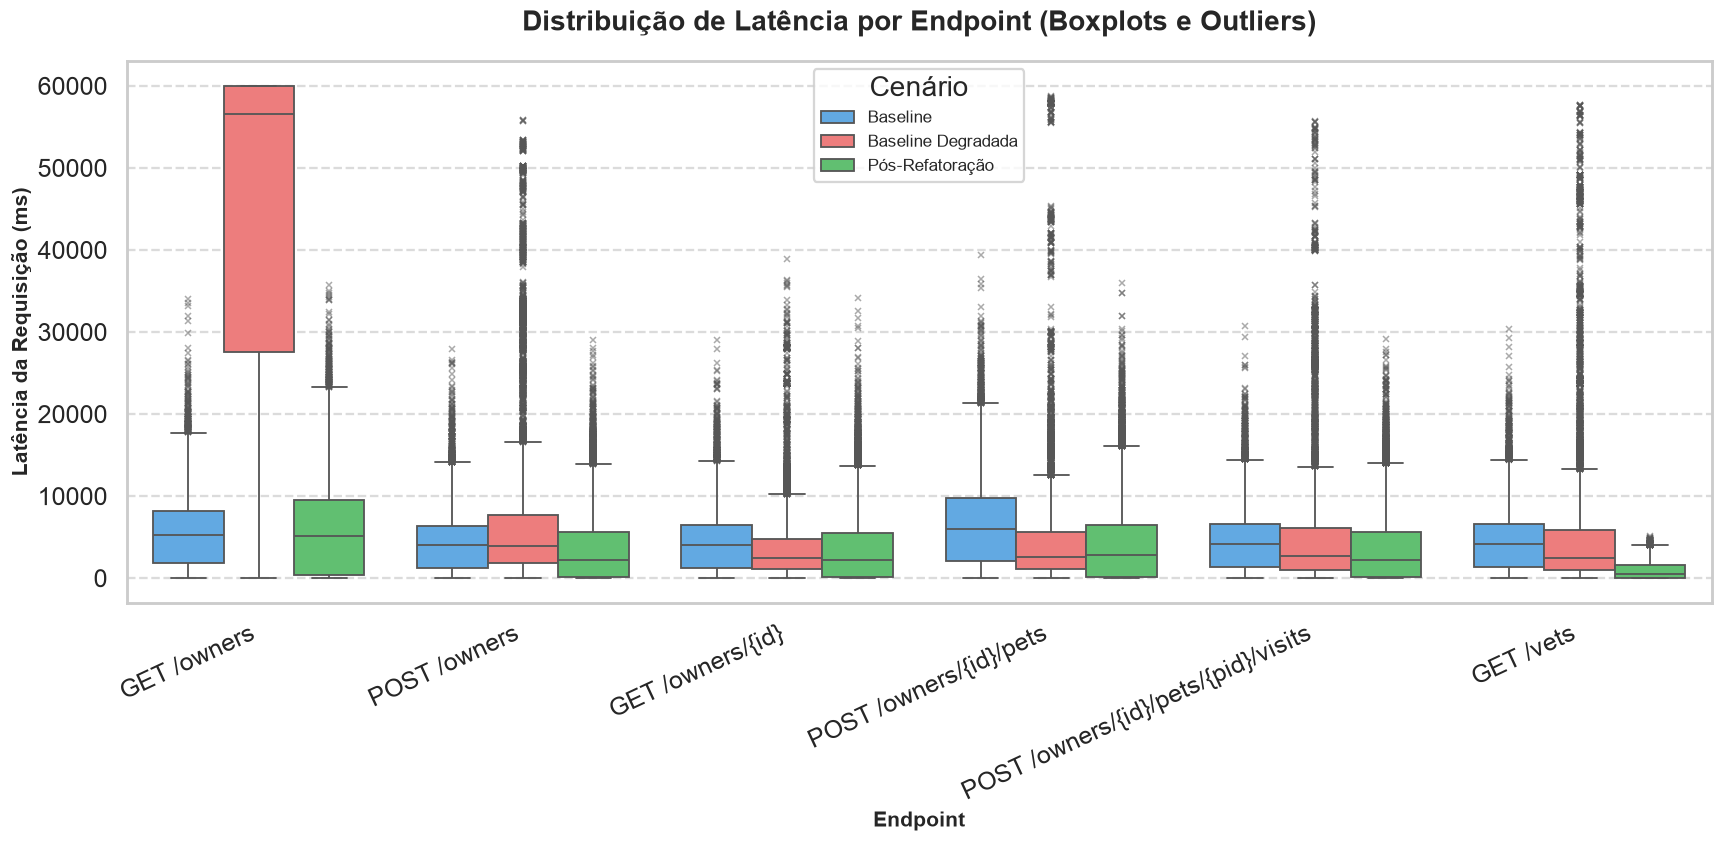

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.1 — Distribuição da latência (ms) por endpoint e cenário (fase steady_state, 5 execuções agregadas por cenário). A caixa mostra Q1–Q3 e a mediana; os marcadores 'x' são outliers, correspondentes aos eventos de cauda longa próximos de p95/p99.</i></div>

In [9]:
def plotar_boxplots_latencia(df_plot: pd.DataFrame):
    plt.figure(figsize=(16, 8))
    sns.boxplot(
        data=df_plot, x="Endpoint", y="metric_value", hue="Cenário",
        palette=PALETA, showfliers=True, linewidth=1.2,
        flierprops={"marker": "x", "markersize": 4, "alpha": 0.5},
    )
    plt.title("Distribuição de Latência por Endpoint (Boxplots e Outliers)", fontsize=18, pad=20)
    plt.xlabel("Endpoint", fontsize=14, fontweight="bold")
    plt.ylabel("Latência da Requisição (ms)", fontsize=14, fontweight="bold")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Cenário", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "boxplot_latencia.png", dpi=300)
    plt.show()

plotar_boxplots_latencia(DF_LATENCIA)
legenda("Figura 4.1 — Distribuição da latência (ms) por endpoint e cenário (fase steady_state, "
        "5 execuções agregadas por cenário). A caixa mostra Q1–Q3 e a mediana; os marcadores 'x' "
        "são outliers, correspondentes aos eventos de cauda longa próximos de p95/p99.")

### 4.4. Densidade da Latência (Violin Plots)

Como complemento ao boxplot, o _violin plot_ combina o diagrama de caixa com a **Estimação de
Densidade de Kernel (KDE)**, revelando onde está o volume real das requisições. Um violino
**baixo e largo** indica latência estável; um violino **esticado e disforme** indica perda de
constância sob carga.


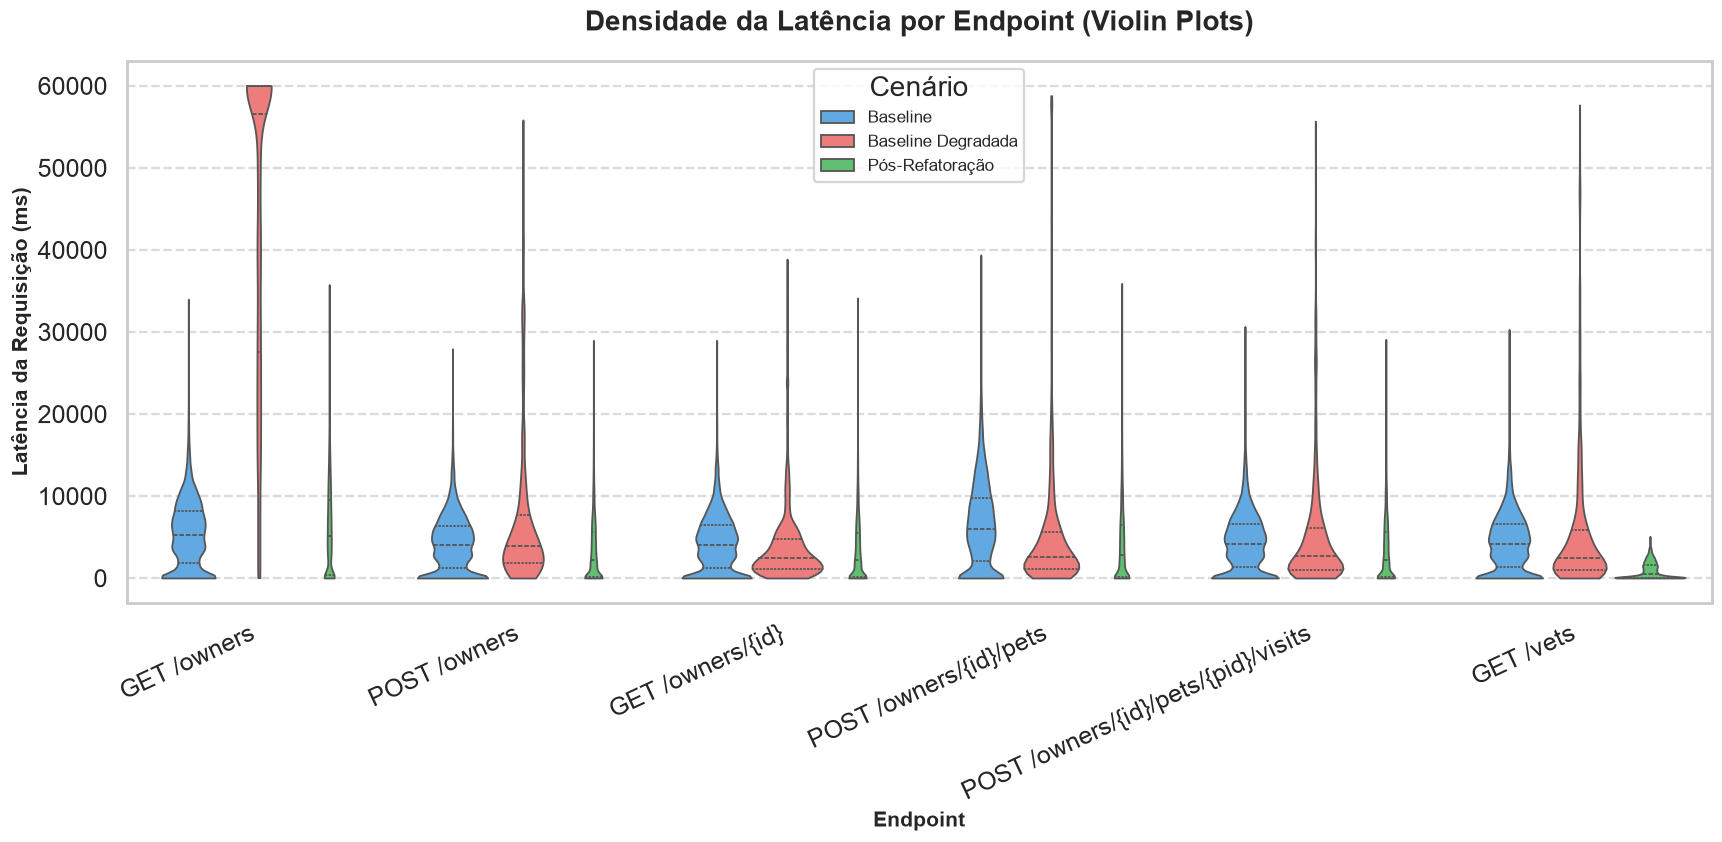

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.2 — Densidade de probabilidade da latência (ms) por endpoint e cenário. As linhas internas marcam os quartis (25%, 50%/mediana, 75%).</i></div>

In [10]:
def plotar_violinplots_latencia(df_plot: pd.DataFrame):
    plt.figure(figsize=(16, 8))
    sns.violinplot(
        data=df_plot, x="Endpoint", y="metric_value", hue="Cenário",
        palette=PALETA, inner="quartile", linewidth=1.2, cut=0,
    )
    plt.title("Densidade da Latência por Endpoint (Violin Plots)", fontsize=18, pad=20)
    plt.xlabel("Endpoint", fontsize=14, fontweight="bold")
    plt.ylabel("Latência da Requisição (ms)", fontsize=14, fontweight="bold")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Cenário", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "violinplot_latencia.png", dpi=300)
    plt.show()

plotar_violinplots_latencia(DF_LATENCIA)
legenda("Figura 4.2 — Densidade de probabilidade da latência (ms) por endpoint e cenário. As "
        "linhas internas marcam os quartis (25%, 50%/mediana, 75%).")

### 4.3. Evolução Dinâmica: _Throughput_ e a "Curva do Joelho" (Séries Temporais)

Conforme Fidelis (2026), a vazão sob estresse não deve ser avaliada apenas pelas médias globais
do JSON, pois sistemas reais saturam de forma não linear. Aqui, o **RPS** (requisições por
segundo) e as falhas são recalculados diretamente do CSV bruto e cruzados no tempo de teste,
para identificar visualmente a **"curva do joelho"**: o instante em que a vazão cai e os erros
começam a se acumular.


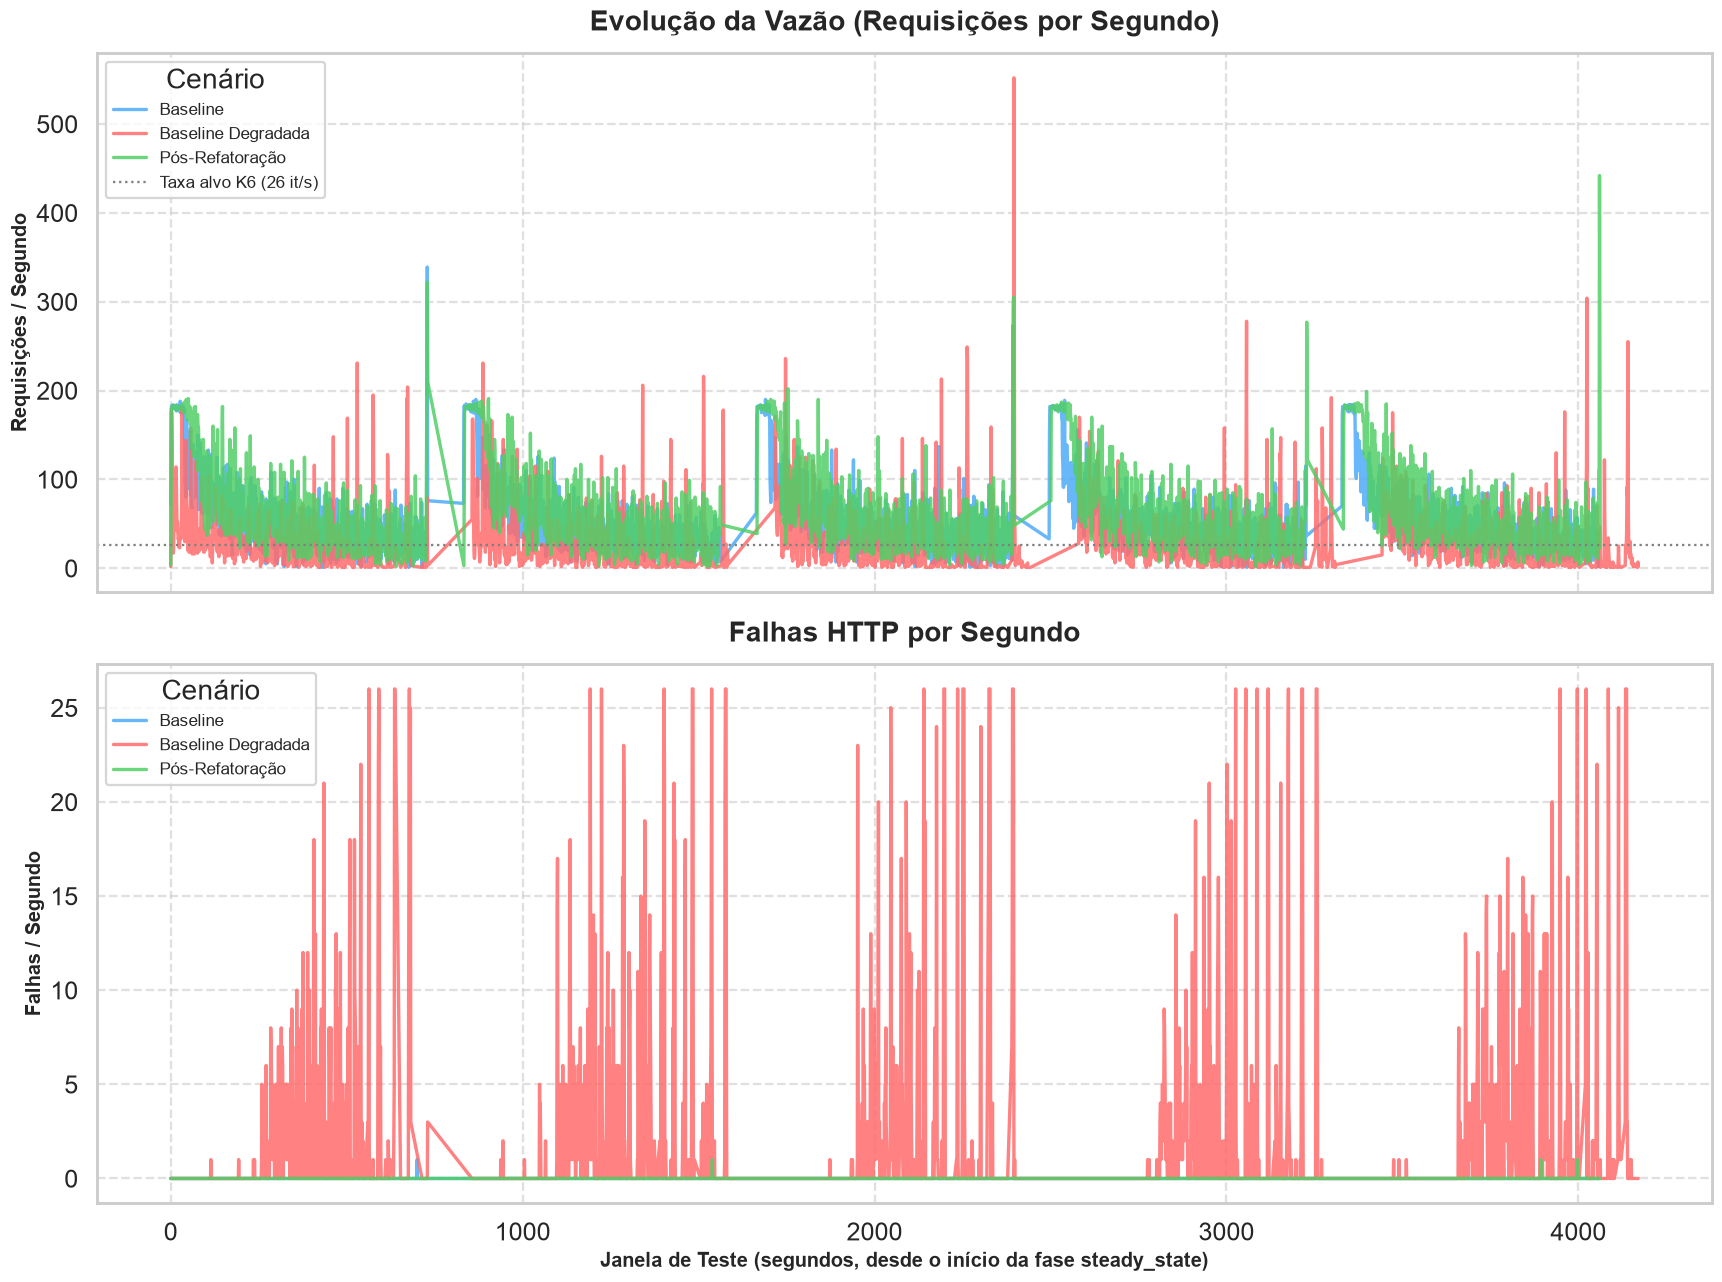

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.3 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) ao longo da fase steady_state, por cenário. A linha pontilhada em 26 req/s marca a taxa alvo do executor constant-arrival-rate; quedas sustentadas abaixo dela, combinadas com dropped_iterations > 0 (Seção 3.1), evidenciam saturação real da branch.</i></div>

In [11]:
def plotar_series_temporais_joelho(dados_k6: dict):
    frames = []
    for nome_cenario, df in dados_k6.items():
        if df.empty:
            continue

        # RPS: 1 requisição por linha de http_req_duration, agrupada por segundo
        df_reqs = df[df["metric_name"] == "http_req_duration"].copy()
        df_reqs["datetime"] = pd.to_datetime(df_reqs["timestamp"], unit="s").dt.floor("s")
        rps = df_reqs.groupby("datetime").size().reset_index(name="RPS")

        # Erros: http_req_failed == 1 significa falha na requisição
        df_fails = df[df["metric_name"] == "http_req_failed"].copy()
        df_fails["datetime"] = pd.to_datetime(df_fails["timestamp"], unit="s").dt.floor("s")
        fails = (df_fails[df_fails["metric_value"] > 0]
                 .groupby("datetime").size().reset_index(name="Erros"))

        df_time = pd.merge(rps, fails, on="datetime", how="left").fillna(0)
        inicio = df_time["datetime"].min()
        df_time["Tempo de Teste (s)"] = (df_time["datetime"] - inicio).dt.total_seconds()
        df_time["Cenário"] = SCENARIOS[nome_cenario]["label"]
        frames.append(df_time)

    if not frames:
        print("Sem dados suficientes para gerar a série temporal.")
        return

    df_plot = pd.concat(frames, ignore_index=True)
    df_plot["Cenário"] = pd.Categorical(df_plot["Cenário"], categories=ORDEM_CENARIOS, ordered=True)

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

    sns.lineplot(data=df_plot, x="Tempo de Teste (s)", y="RPS", hue="Cenário",
                 palette=PALETA, ax=axes[0], linewidth=2.2, alpha=0.85)
    axes[0].set_title("Evolução da Vazão (Requisições por Segundo)", fontsize=18, pad=15)
    axes[0].set_ylabel("Requisições / Segundo", fontsize=13, fontweight="bold")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].axhline(26, color="gray", linestyle=":", linewidth=1.5, label="Taxa alvo K6 (26 it/s)")

    sns.lineplot(data=df_plot, x="Tempo de Teste (s)", y="Erros", hue="Cenário",
                 palette=PALETA, ax=axes[1], linewidth=2.2, alpha=0.85)
    axes[1].set_title("Falhas HTTP por Segundo", fontsize=18, pad=15)
    axes[1].set_xlabel("Janela de Teste (segundos, desde o início da fase steady_state)", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("Falhas / Segundo", fontsize=13, fontweight="bold")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    for ax in axes:
        ax.legend(title="Cenário", fontsize=11)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "serie_temporal_joelho.png", dpi=300)
    plt.show()

plotar_series_temporais_joelho(dados_k6)
legenda("Figura 4.3 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) "
        "ao longo da fase steady_state, por cenário. A linha pontilhada em 26 req/s marca a "
        "taxa alvo do executor constant-arrival-rate; quedas sustentadas abaixo dela, "
        "combinadas com dropped_iterations > 0 (Seção 3.1), evidenciam saturação real da branch.")

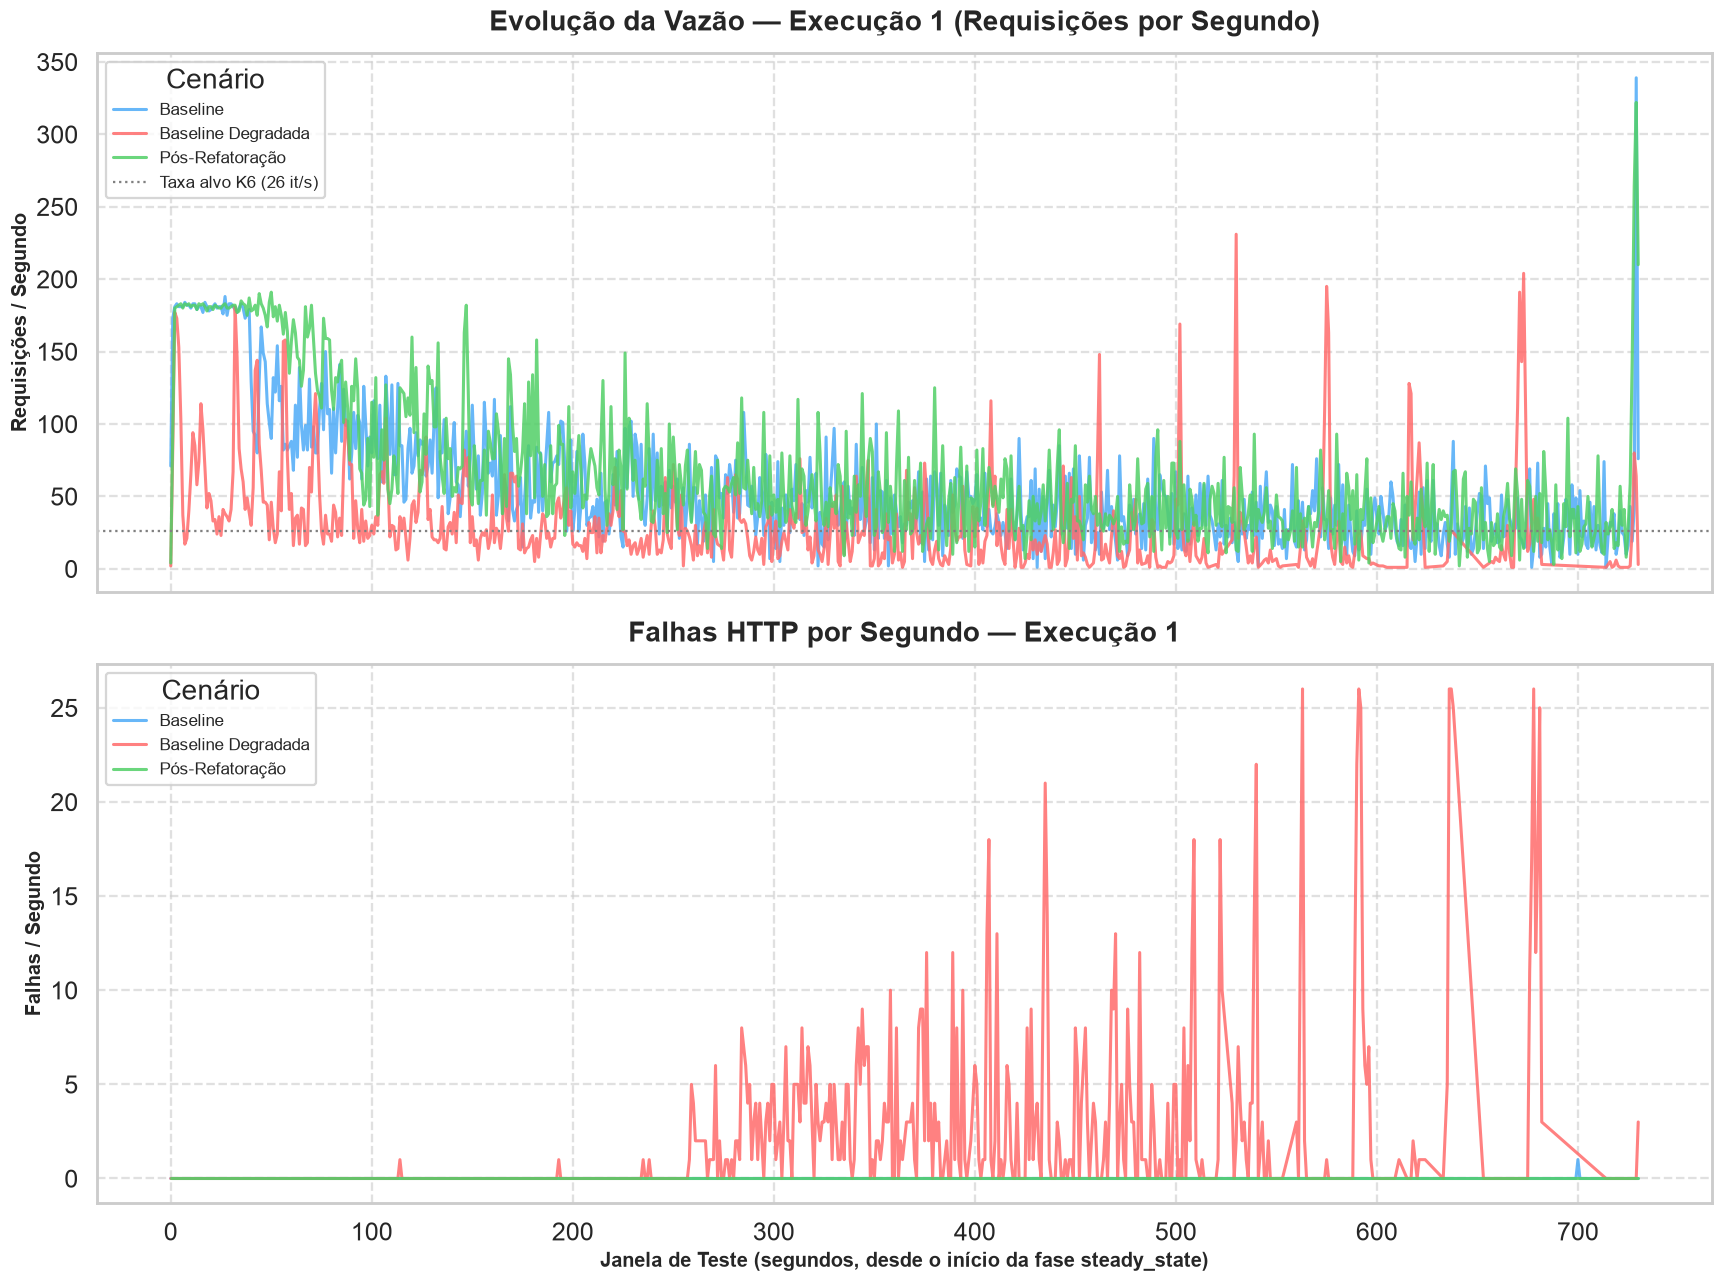

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.3.1 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) na Execução 1, isolada por cenário. Comparação par a par entre as branches nesta mesma rodada, sem a sobreposição das demais execuções — útil para verificar se o padrão de saturação da Figura 4.3 é consistente rodada a rodada, ou concentrado em uma execução específica.</i></div>

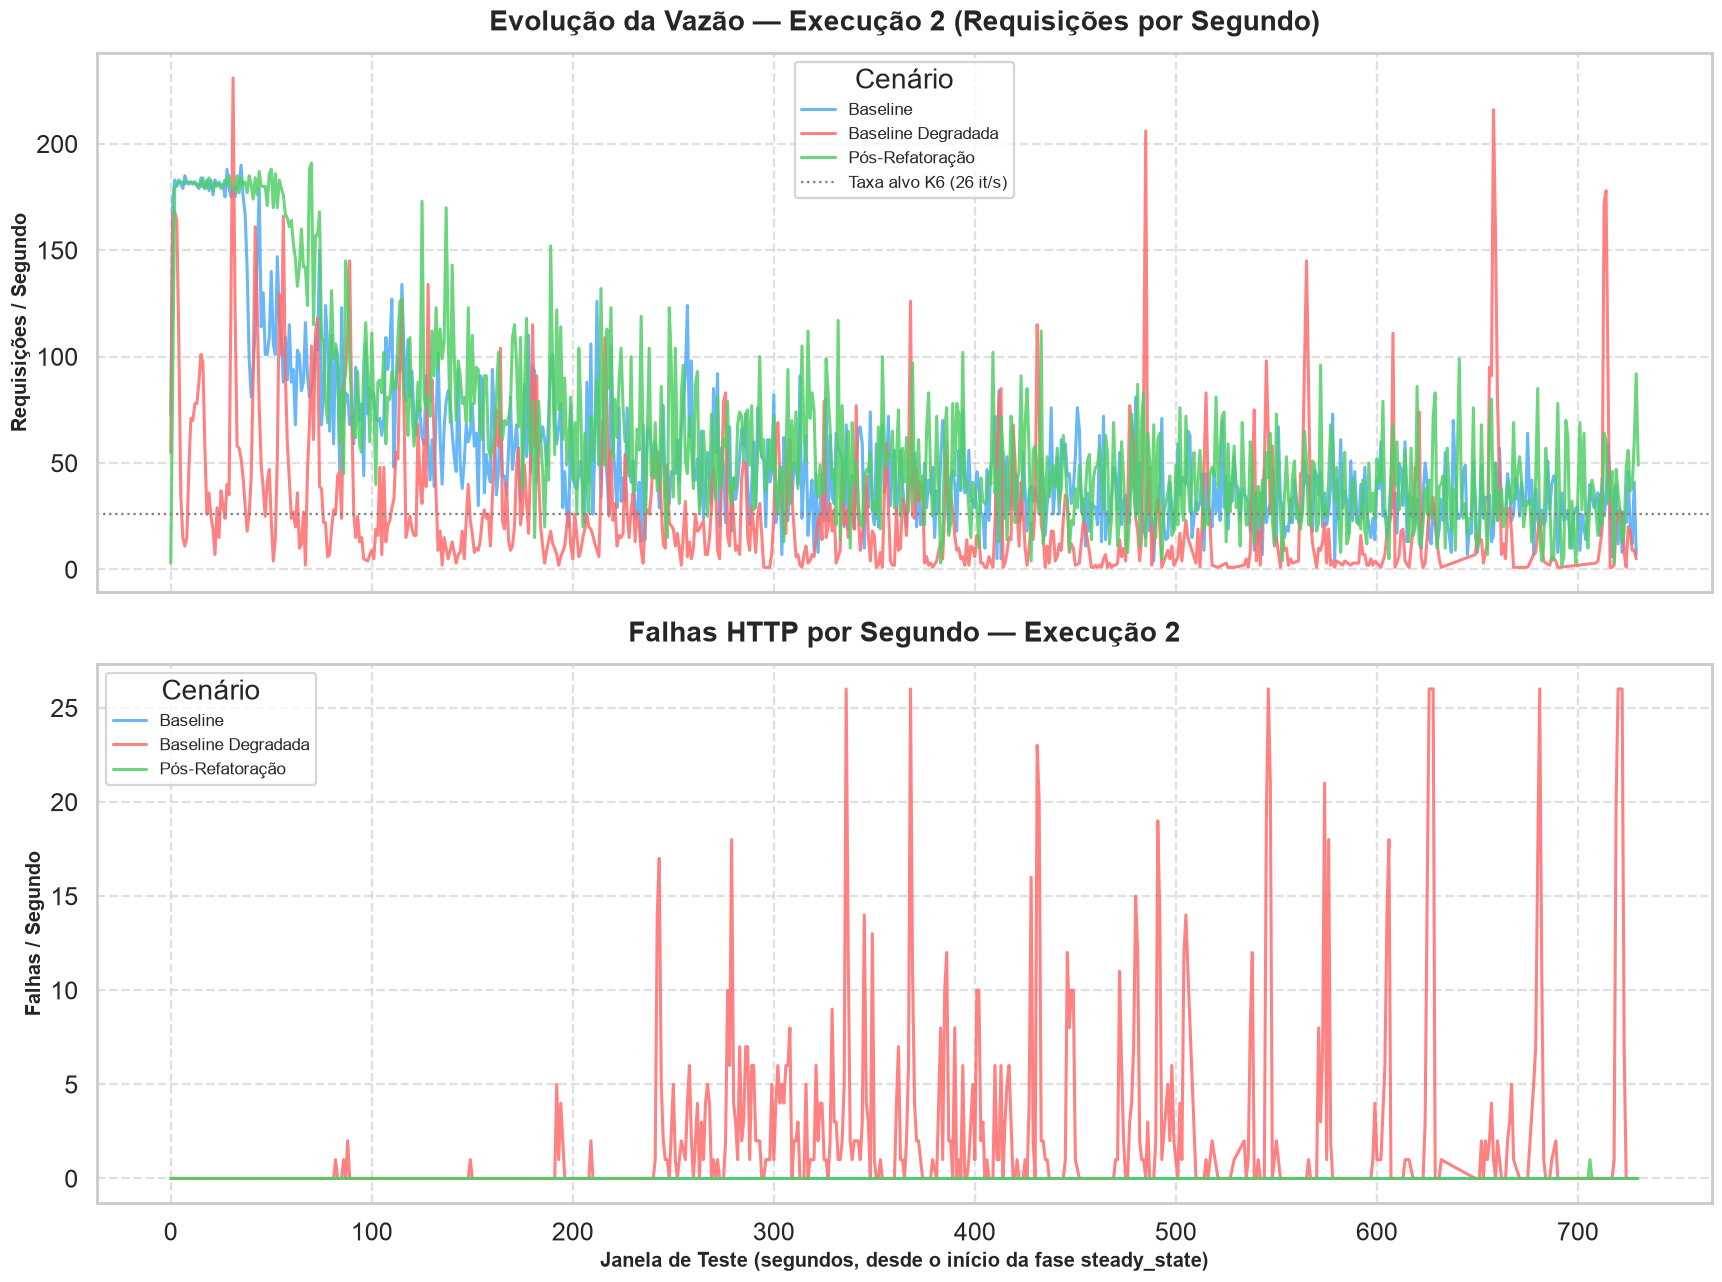

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.3.2 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) na Execução 2, isolada por cenário. Comparação par a par entre as branches nesta mesma rodada, sem a sobreposição das demais execuções — útil para verificar se o padrão de saturação da Figura 4.3 é consistente rodada a rodada, ou concentrado em uma execução específica.</i></div>

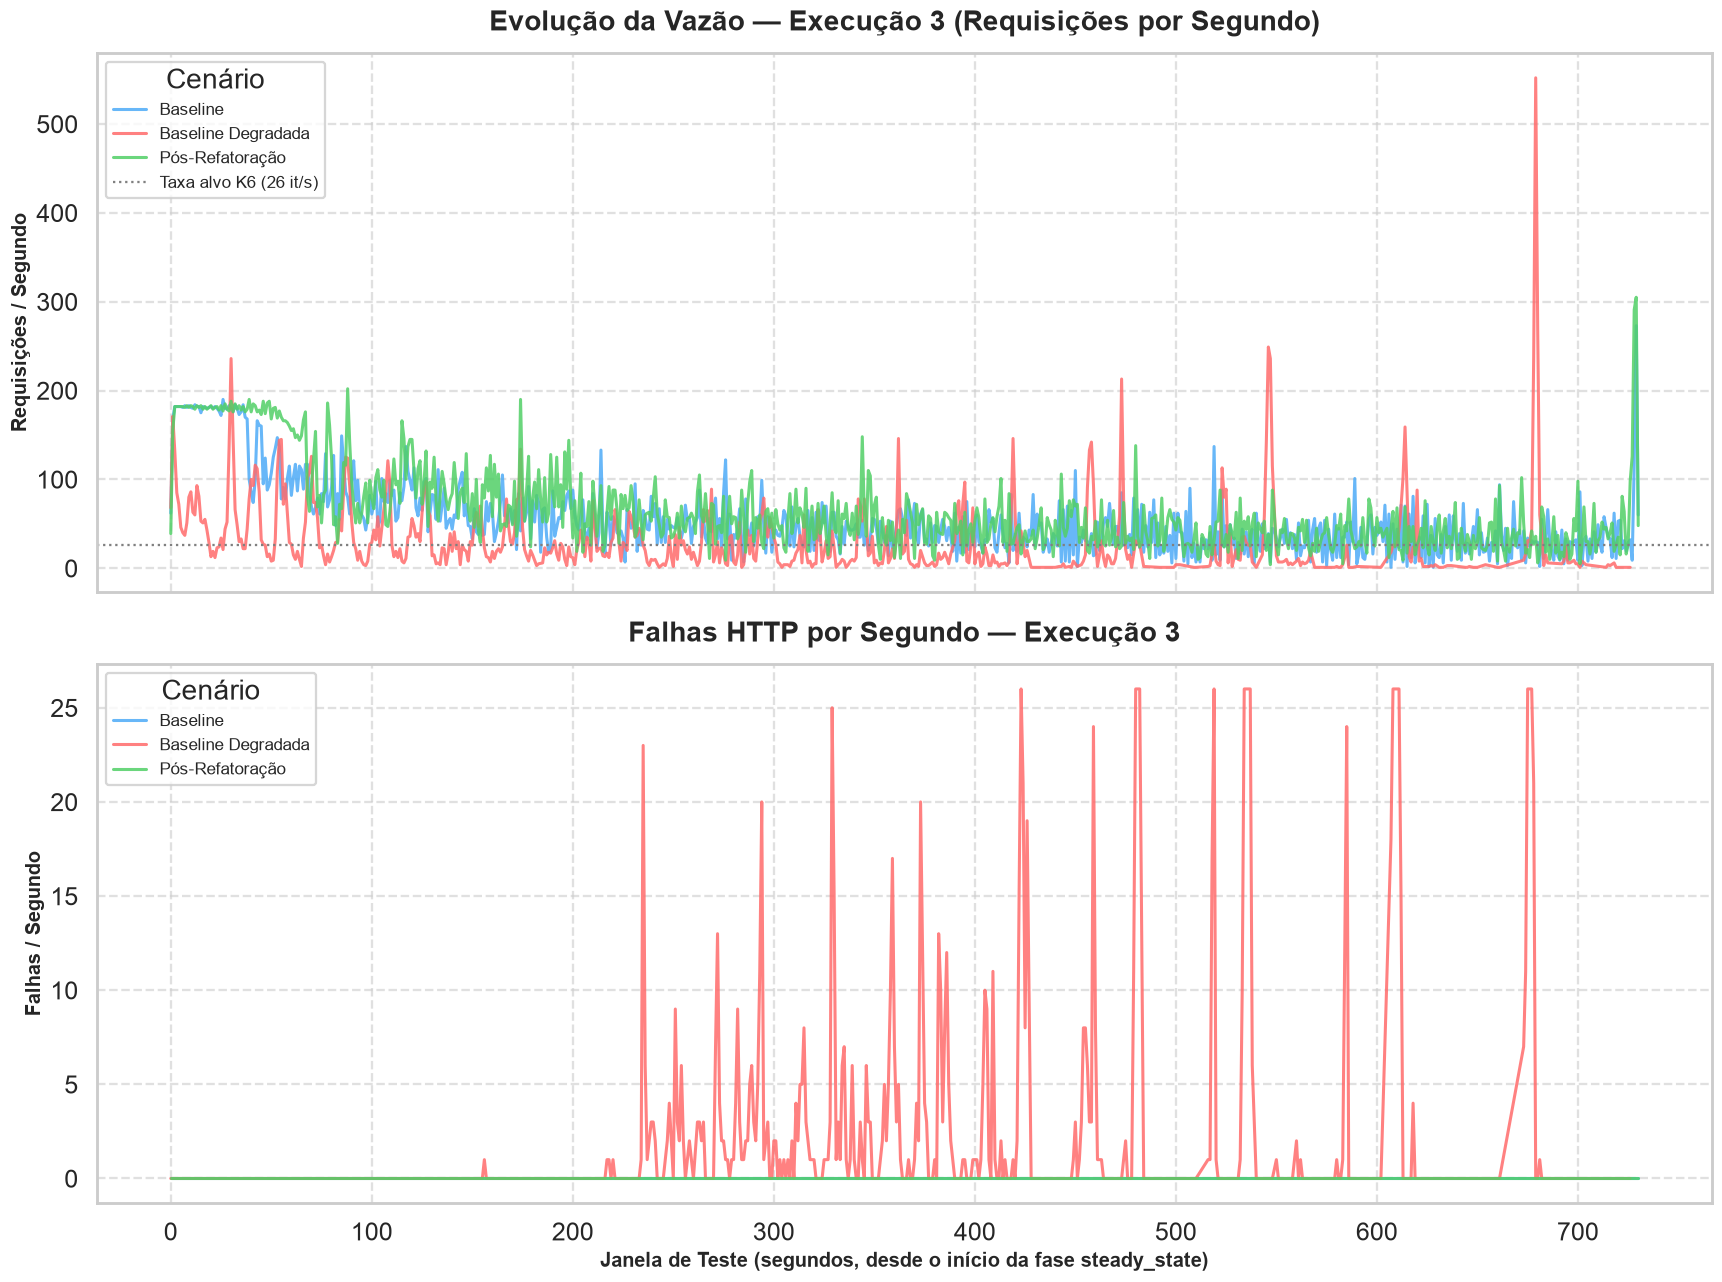

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.3.3 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) na Execução 3, isolada por cenário. Comparação par a par entre as branches nesta mesma rodada, sem a sobreposição das demais execuções — útil para verificar se o padrão de saturação da Figura 4.3 é consistente rodada a rodada, ou concentrado em uma execução específica.</i></div>

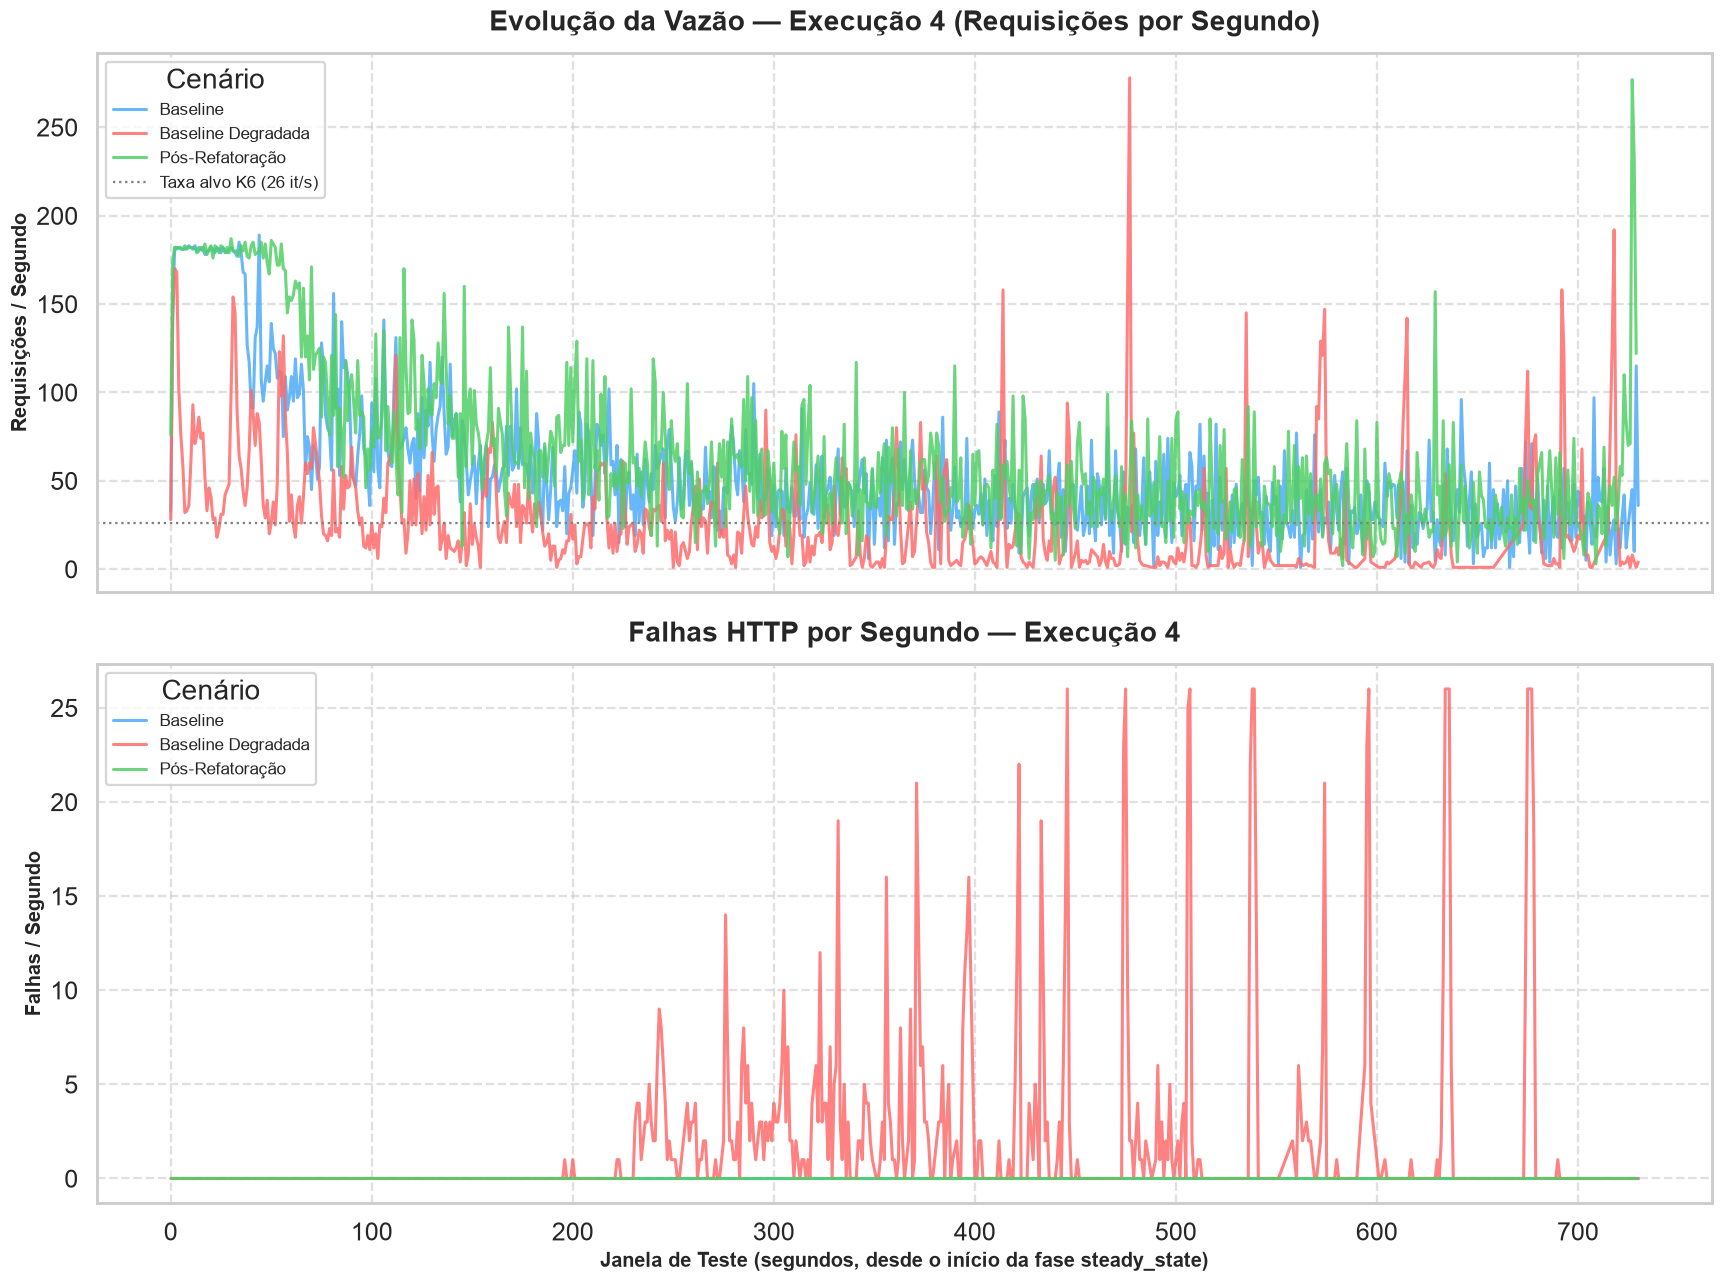

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.3.4 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) na Execução 4, isolada por cenário. Comparação par a par entre as branches nesta mesma rodada, sem a sobreposição das demais execuções — útil para verificar se o padrão de saturação da Figura 4.3 é consistente rodada a rodada, ou concentrado em uma execução específica.</i></div>

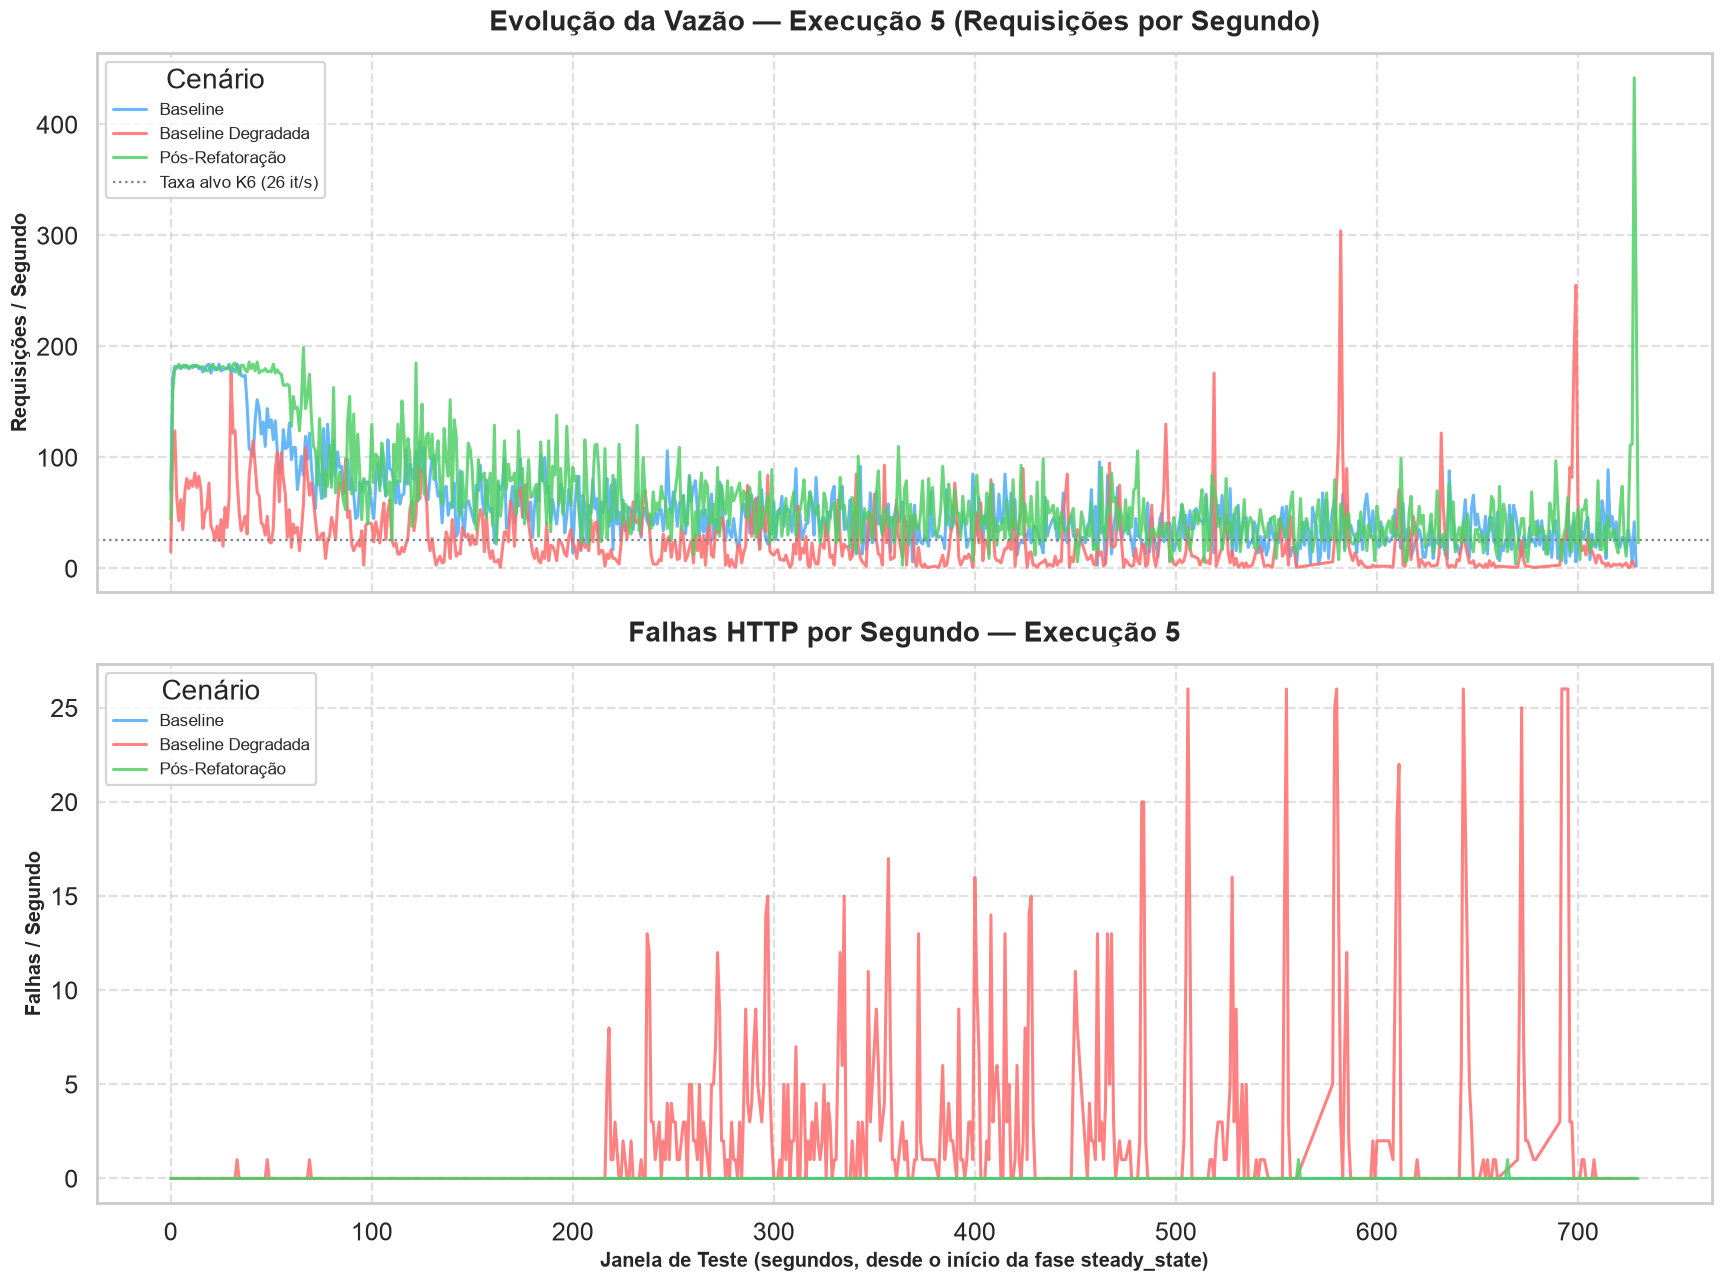

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 4.3.5 — Vazão (RPS, painel superior) e falhas HTTP por segundo (painel inferior) na Execução 5, isolada por cenário. Comparação par a par entre as branches nesta mesma rodada, sem a sobreposição das demais execuções — útil para verificar se o padrão de saturação da Figura 4.3 é consistente rodada a rodada, ou concentrado em uma execução específica.</i></div>

In [12]:
def plotar_series_temporais_joelho_por_execucao(dados_k6: dict):
    """Mesma lógica da Figura 4.3, mas isolando cada execução (run) em uma figura própria,
    para inspecionar se o padrão de saturação se repete rodada a rodada ou é dominado por
    uma execução específica (a sobreposição das 5 execuções na Fig. 4.3 pode mascarar isso)."""
    runs_disponiveis = sorted(set().union(
        *[set(df["run"].unique()) for df in dados_k6.values() if not df.empty]
    ))

    for run_n in runs_disponiveis:
        frames = []
        for nome_cenario, df in dados_k6.items():
            df_run = df[df["run"] == run_n]
            if df_run.empty:
                continue

            df_reqs = df_run[df_run["metric_name"] == "http_req_duration"].copy()
            df_reqs["datetime"] = pd.to_datetime(df_reqs["timestamp"], unit="s").dt.floor("s")
            rps = df_reqs.groupby("datetime").size().reset_index(name="RPS")

            df_fails = df_run[df_run["metric_name"] == "http_req_failed"].copy()
            df_fails["datetime"] = pd.to_datetime(df_fails["timestamp"], unit="s").dt.floor("s")
            fails = (df_fails[df_fails["metric_value"] > 0]
                     .groupby("datetime").size().reset_index(name="Erros"))

            df_time = pd.merge(rps, fails, on="datetime", how="left").fillna(0)
            inicio = df_time["datetime"].min()
            df_time["Tempo de Teste (s)"] = (df_time["datetime"] - inicio).dt.total_seconds()
            df_time["Cenário"] = SCENARIOS[nome_cenario]["label"]
            frames.append(df_time)

        if not frames:
            continue

        df_plot = pd.concat(frames, ignore_index=True)
        df_plot["Cenário"] = pd.Categorical(df_plot["Cenário"], categories=ORDEM_CENARIOS, ordered=True)

        fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

        sns.lineplot(data=df_plot, x="Tempo de Teste (s)", y="RPS", hue="Cenário",
                     palette=PALETA, ax=axes[0], linewidth=2.0, alpha=0.85)
        axes[0].set_title(f"Evolução da Vazão — Execução {run_n} (Requisições por Segundo)",
                           fontsize=18, pad=15)
        axes[0].set_ylabel("Requisições / Segundo", fontsize=13, fontweight="bold")
        axes[0].grid(True, linestyle="--", alpha=0.6)
        axes[0].axhline(26, color="gray", linestyle=":", linewidth=1.5, label="Taxa alvo K6 (26 it/s)")

        sns.lineplot(data=df_plot, x="Tempo de Teste (s)", y="Erros", hue="Cenário",
                     palette=PALETA, ax=axes[1], linewidth=2.0, alpha=0.85)
        axes[1].set_title(f"Falhas HTTP por Segundo — Execução {run_n}", fontsize=18, pad=15)
        axes[1].set_xlabel("Janela de Teste (segundos, desde o início da fase steady_state)",
                            fontsize=13, fontweight="bold")
        axes[1].set_ylabel("Falhas / Segundo", fontsize=13, fontweight="bold")
        axes[1].grid(True, linestyle="--", alpha=0.6)

        for ax in axes:
            ax.legend(title="Cenário", fontsize=11)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"serie_temporal_joelho_run{run_n}.png", dpi=300)
        plt.show()

        legenda(f"Figura 4.3.{run_n} — Vazão (RPS, painel superior) e falhas HTTP por segundo "
                f"(painel inferior) na Execução {run_n}, isolada por cenário. Comparação par a "
                f"par entre as branches nesta mesma rodada, sem a sobreposição das demais "
                f"execuções — útil para verificar se o padrão de saturação da Figura 4.3 é "
                f"consistente rodada a rodada, ou concentrado em uma execução específica.")


plotar_series_temporais_joelho_por_execucao(dados_k6)

## 5. Métricas Estáticas (PMD e ArchUnit) — Débito Técnico Estrutural

Esta seção atende diretamente à Seção 5.1 do estudo de caso (_"Exibir os scores de PMD e regras
do ArchUnit na versão Baseline Degradada vs. Pós-Refatoração. Prove numericamente que o débito
técnico estrutural foi mitigado."_. Os três cenários são
mantidos lado a lado para reforçar a leitura "antes → injeção do débito → depois".


In [13]:
def carregar_pmd_csv(filepath) -> pd.DataFrame:
    if filepath is None or not Path(filepath).exists():
        return pd.DataFrame()
    df = pd.read_csv(filepath, dtype=str)
    df.columns = [c.strip() for c in df.columns]
    return df


def contar_violacoes_pmd(df_pmd: pd.DataFrame) -> dict:
    if df_pmd.empty or "Rule" not in df_pmd.columns:
        return {}
    return df_pmd["Rule"].value_counts().to_dict()


pmd_dados, pmd_contagens = {}, {}
for nome_cenario in SCENARIOS:
    pmd_dados[nome_cenario] = carregar_pmd_csv(RESOLVED_PATHS[nome_cenario]["pmd_csv"])
    pmd_contagens[nome_cenario] = contar_violacoes_pmd(pmd_dados[nome_cenario])

# Regras acompanhadas conforme o ruleset.xml documentado em 01_Variaveis_e_Metricas.md §2
REGRAS_INTERESSE = [
    "CyclomaticComplexity", "LawOfDemeter", "GodClass",
    "CouplingBetweenObjects", "DataClass", "ExcessiveMethodLength", "NcssCount",
]
linhas_pmd = [
    {
        "Rule": regra,
        "Baseline": pmd_contagens["baseline"].get(regra, 0),
        "Baseline Degradada": pmd_contagens["degradada"].get(regra, 0),
        "Pós-Refatoração": pmd_contagens["pos_refatoracao"].get(regra, 0),
    }
    for regra in REGRAS_INTERESSE
]
df_pmd_simples = pd.DataFrame(linhas_pmd).set_index("Rule")

display(Markdown("#### Contagem de violações PMD por regra e cenário"))

def destacar_regras_chave(s):
    # CC, LawOfDemeter e GodClass são as regras diretamente ligadas à hipótese central
    cor = "background-color: #ffe066; color: black"
    return [cor] * len(s) if s.name in ["CyclomaticComplexity", "LawOfDemeter", "GodClass"] else [""] * len(s)

display(df_pmd_simples.style.apply(destacar_regras_chave, axis=1))
legenda("Tabela 5.1 — Número de violações por regra PMD (linhas destacadas: regras "
        "diretamente associadas à hipótese central de acoplamento/coesão). DataClass é "
        "constante nos três cenários (não foi alvo de degradação/refatoração) — mantida "
        "como referência de estabilidade da análise estática. Regras com 0 em todos os "
        "cenários (ex.: ExcessiveMethodLength/NcssCount, se aplicável) indicam ausência "
        "desse smell específico nos dados coletados, não erro de leitura.")

#### Contagem de violações PMD por regra e cenário

,Baseline,Baseline Degradada,Pós-Refatoração
Rule,,,
CyclomaticComplexity,0,5,0
LawOfDemeter,3,6,3
GodClass,0,1,0
CouplingBetweenObjects,2,2,2
DataClass,7,7,7
ExcessiveMethodLength,0,0,0
NcssCount,0,0,0


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 5.1 — Número de violações por regra PMD (linhas destacadas: regras diretamente associadas à hipótese central de acoplamento/coesão). DataClass é constante nos três cenários (não foi alvo de degradação/refatoração) — mantida como referência de estabilidade da análise estática. Regras com 0 em todos os cenários (ex.: ExcessiveMethodLength/NcssCount, se aplicável) indicam ausência desse smell específico nos dados coletados, não erro de leitura.</i></div>

In [14]:
def parsear_archunit_txt(filepath):
    """Extrai a tabela de acoplamento (Ca/Ce/Instabilidade/Abstração) por pacote a partir
    do log textual gerado pelo ValidacaoArquiteturalTest."""
    if filepath is None or not Path(filepath).exists():
        return pd.DataFrame()
    texto = Path(filepath).read_text(encoding="utf-8", errors="ignore")
    padrao_linha = re.compile(r"║\s*([\w.]+)\s*│\s*([\d,]+)\s*│\s*([\d,]+)\s*│\s*([\d,]+)\s*│\s*([\d,]+)\s*║")
    registros = []
    for pacote, ca, ce, i_val, a_val in padrao_linha.findall(texto):
        if pacote.strip().lower() == "pacote":
            continue
        try:
            registros.append({
                "pacote": pacote.strip(),
                "Ca": int(ca.replace(",", "")), "Ce": int(ce.replace(",", "")),
                "I": float(i_val.replace(",", ".")), "A": float(a_val.replace(",", ".")),
            })
        except ValueError:
            continue
    return pd.DataFrame(registros)


archunit_dados = {nome: parsear_archunit_txt(RESOLVED_PATHS[nome]["archunit_txt"]) for nome in SCENARIOS}

dfs_arch = []
for cenario_key, df_ac in archunit_dados.items():
    if not df_ac.empty:
        df_ac = df_ac.set_index("pacote")
        df_ac.columns = [f"{c}_{SCENARIOS[cenario_key]['label']}" for c in df_ac.columns]
        dfs_arch.append(df_ac)

if dfs_arch:
    df_arch_simples = pd.concat(dfs_arch, axis=1).fillna(0)
    display(Markdown("#### Métricas de acoplamento por pacote (Ca = Fan-In, Ce = Fan-Out, "
                      "I = Instabilidade, A = Abstração) — ISO/IEC 25010, Manutenibilidade"))

    def destacar_pacotes_criticos(s):
        cor = "background-color: #ffe066; color: black"
        return [cor] * len(s) if s.name in ["rest", "repository"] else [""] * len(s)

    display(df_arch_simples.style.apply(destacar_pacotes_criticos, axis=1))
    legenda("Tabela 5.2 — Métricas de acoplamento por pacote. Pacotes destacados (rest, "
            "repository) são os diretamente envolvidos na violação de camadas injetada "
            "(controller acessando repository) e sua correção pós-refatoração.")

    # Falhas de teste do ArchUnit — evidência textual da violação de arquitetura por cenário
    display(Markdown("#### Resultado da suíte ValidacaoArquiteturalTest por cenário"))
    html_content = ""
    for cenario_key, cfg in SCENARIOS.items():
        filepath = RESOLVED_PATHS[cenario_key]["archunit_txt"]
        if not Path(filepath).exists():
            continue
        texto = Path(filepath).read_text(encoding="utf-8", errors="ignore")
        match = re.search(r"\[ERROR\] Failures:(.*?)(?:\[INFO\]\s*\[ERROR\] Tests run:)", texto, re.DOTALL)
        if match:
            failure_text = match.group(1).strip().replace("[ERROR]", "")
            html_content += (
                "<div style='background-color:#ffe6e6;border-left:5px solid #ff4d4d;"
                "padding:10px;margin-bottom:10px;border-radius:5px'>"
                f"<h4 style='color:#cc0000;margin-top:0'>{cfg['label']} — Violação Encontrada</h4>"
                f"<pre style='white-space:pre-wrap;font-size:13px;color:#333'>{failure_text}</pre></div>"
            )
        else:
            html_content += (
                "<div style='background-color:#e6ffe6;border-left:5px solid #4dff4d;"
                "padding:10px;margin-bottom:10px;border-radius:5px'>"
                f"<h4 style='color:#008000;margin-top:0'>{cfg['label']} — Nenhuma Falha (Arquitetura Válida)</h4></div>"
            )
    display(HTML(html_content))

#### Métricas de acoplamento por pacote (Ca = Fan-In, Ce = Fan-Out, I = Instabilidade, A = Abstração) — ISO/IEC 25010, Manutenibilidade

,Ca_Baseline,Ce_Baseline,I_Baseline,A_Baseline,Ca_Baseline Degradada,Ce_Baseline Degradada,I_Baseline Degradada,A_Baseline Degradada,Ca_Pós-Refatoração,Ce_Pós-Refatoração,I_Pós-Refatoração,A_Pós-Refatoração
pacote,,,,,,,,,,,,
rest,1,3,0.750000,0.263000,1,4,0.800000,0.263000,1,3,0.750000,0.263000
security,0,0,1.000000,0.000000,0,0,1.000000,0.000000,0,0,1.000000,0.000000
util,1,1,0.500000,0.500000,1,1,0.500000,0.500000,1,1,0.500000,0.500000
service,1,2,0.667000,0.500000,1,2,0.667000,0.500000,1,2,0.667000,0.500000
mapper,1,2,0.667000,0.500000,1,2,0.667000,0.500000,1,2,0.667000,0.500000
model,5,0,0.000000,0.000000,5,0,0.000000,0.000000,5,0,0.000000,0.000000
repository,1,2,0.667000,0.462000,2,2,0.500000,0.462000,1,2,0.667000,0.462000
config,0,0,1.000000,0.000000,0,0,1.000000,0.000000,0,0,1.000000,0.000000


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 5.2 — Métricas de acoplamento por pacote. Pacotes destacados (rest, repository) são os diretamente envolvidos na violação de camadas injetada (controller acessando repository) e sua correção pós-refatoração.</i></div>

#### Resultado da suíte ValidacaoArquiteturalTest por cenário

### 5.1. Evolução do Débito Técnico (Gráfico de Radar)

O **gráfico de radar** é adequado para métricas estáticas multivariadas: a "área" do polígono
representa visualmente o volume agregado de más práticas. O polígono deve "estourar" no cenário
Degradado e retrair ao formato original no Pós-Refatoração.


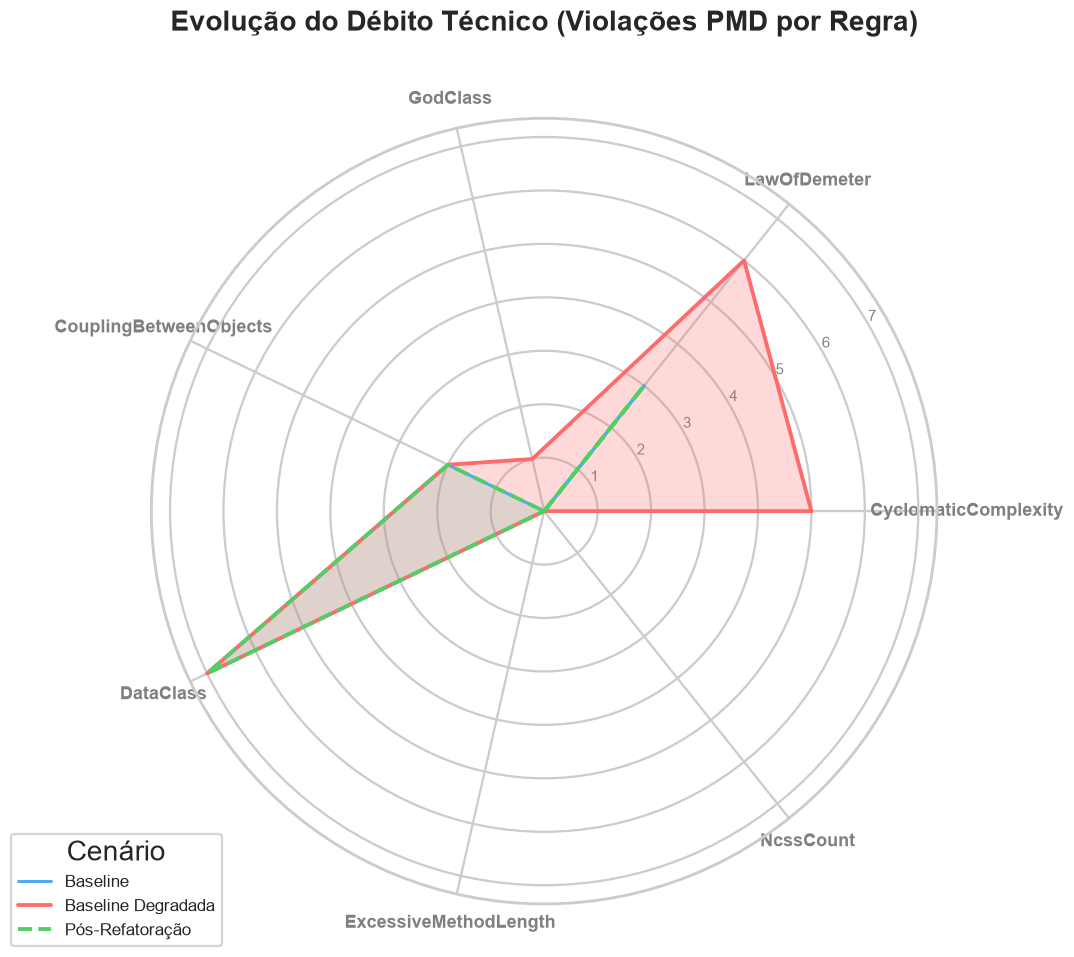

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Figura 5.1 — Radar comparando o número de violações por regra PMD entre os três cenários. Como os valores são contagens pequenas (0–10 aprox.), a escala não foi normalizada; caso a diferença de escala entre regras cresça no seu conjunto de dados final, normalize cada eixo para [0,1] antes de plotar para evitar que uma única regra domine visualmente o polígono.</i></div>

In [15]:
def plotar_grafico_radar_pmd(df_pmd: pd.DataFrame):
    categorias = df_pmd.index.tolist()
    N = len(categorias)

    valores_baseline = df_pmd["Baseline"].values.tolist()
    valores_degradada = df_pmd["Baseline Degradada"].values.tolist()
    valores_refatorada = df_pmd["Pós-Refatoração"].values.tolist()

    # Fecha o polígono repetindo o primeiro valor
    valores_baseline += valores_baseline[:1]
    valores_degradada += valores_degradada[:1]
    valores_refatorada += valores_refatorada[:1]

    angulos = [n / float(N) * 2 * np.pi for n in range(N)]
    angulos += angulos[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    plt.xticks(angulos[:-1], categorias, color="grey", size=12, fontweight="bold")
    ax.set_rlabel_position(30)
    plt.yticks(color="grey", size=10)

    ax.plot(angulos, valores_baseline, linewidth=2, linestyle="solid",
            label="Baseline", color=SCENARIOS["baseline"]["color"])
    ax.fill(angulos, valores_baseline, color=SCENARIOS["baseline"]["color"], alpha=0.1)

    ax.plot(angulos, valores_degradada, linewidth=2.5, linestyle="solid",
            label="Baseline Degradada", color=SCENARIOS["degradada"]["color"])
    ax.fill(angulos, valores_degradada, color=SCENARIOS["degradada"]["color"], alpha=0.25)

    ax.plot(angulos, valores_refatorada, linewidth=2.5, linestyle="dashed",
            label="Pós-Refatoração", color=SCENARIOS["pos_refatoracao"]["color"])
    ax.fill(angulos, valores_refatorada, color=SCENARIOS["pos_refatoracao"]["color"], alpha=0.1)

    plt.title("Evolução do Débito Técnico (Violações PMD por Regra)", size=18, y=1.1)
    plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1), fontsize=11, title="Cenário")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "radar_metricas_estaticas.png", dpi=300)
    plt.show()

plotar_grafico_radar_pmd(df_pmd_simples)
legenda("Figura 5.1 — Radar comparando o número de violações por regra PMD entre os três "
        "cenários. Como os valores são contagens pequenas (0–10 aprox.), a escala não foi "
        "normalizada; caso a diferença de escala entre regras cresça no seu conjunto de "
        "dados final, normalize cada eixo para [0,1] antes de plotar para evitar que uma "
        "única regra domine visualmente o polígono.")

### 5.2. Tabela Síntese — Comparativo de Violações Estruturais (PMD + ArchUnit)

As Tabelas 5.1 e 5.2 acima expõem o conjunto **completo** de regras e pacotes monitorados —
material de apoio útil para auditoria, mas extenso demais para reprodução direta no corpo do
texto do Capítulo 5. Esta tabela restringe-se às métricas que **de fato variaram** entre os
cenários: do PMD, apenas `CyclomaticComplexity`, `LawOfDemeter` e `GodClass` — as demais regras
monitoradas (`DataClass`, `ExcessiveMethodLength`, `NcssCount`) permaneceram constantes nos três
cenários, pois capturam anomalias em outras classes do projeto, não afetadas pela intervenção
experimental. Do ArchUnit, apenas os pacotes `rest` e `repository` — os dois diretamente
envolvidos na violação de camada injetada (Controller acessando Repository) —, com as quatro
métricas de acoplamento (Ca, Ce, I, A) lado a lado; os pacotes `security`, `util`, `service`,
`mapper`, `model` e `config` foram omitidos por serem idênticos em todos os cenários, servindo
apenas como referência de estabilidade (já demonstrada na Tabela 5.2 completa). Pronta para ser
referenciada como "Tabela 2" no texto, com cada linha correspondendo a uma afirmação específica
do parágrafo da Seção 5.1.

In [16]:
def contar_violacoes_layer_archunit(filepath) -> int:
    """Soma o total de violações reportadas pela suíte ValidacaoArquiteturalTest
    (padrão 'was violated (N times)' no log textual do ArchUnit)."""
    if filepath is None or not Path(filepath).exists():
        return 0
    texto = Path(filepath).read_text(encoding="utf-8", errors="ignore")
    ocorrencias = re.findall(r"was violated \((\d+) times\)", texto)
    return sum(int(n) for n in ocorrencias)


def montar_tabela_sintese_estrutural() -> pd.DataFrame:
    """Consolida, em uma única tabela, apenas as métricas estáticas que de fato variaram
    entre os três cenários: violações PMD selecionadas (CC, LawOfDemeter, GodClass) e as
    quatro métricas de acoplamento (Ca/Ce/I/A, ArchUnit) dos pacotes 'rest' e 'repository' —
    os únicos diretamente envolvidos na violação de camada injetada — além da contagem total
    de violações de camada detectadas pela suíte de testes."""
    linhas = []

    regras_sintese = ["CyclomaticComplexity", "LawOfDemeter", "GodClass"]
    for regra in regras_sintese:
        linhas.append({
            "Métrica": f"{regra} — violações (PMD)",
            "Baseline": pmd_contagens["baseline"].get(regra, 0),
            "Baseline Degradada": pmd_contagens["degradada"].get(regra, 0),
            "Pós-Refatoração": pmd_contagens["pos_refatoracao"].get(regra, 0),
        })

    pacotes_sintese = ["rest", "repository"]
    metricas_arch = ["Ca", "Ce", "I", "A"]
    for pacote in pacotes_sintese:
        for metrica in metricas_arch:
            linha = {"Métrica": f"{pacote} — {metrica} (ArchUnit)"}
            for cenario_key, cfg in SCENARIOS.items():
                df_ac = archunit_dados[cenario_key]
                valor = df_ac.set_index("pacote")[metrica].get(pacote, np.nan) if not df_ac.empty else np.nan
                linha[cfg["label"]] = valor
            linhas.append(linha)

    linha_violacoes = {"Métrica": "Violações de camada detectadas — ArchUnit"}
    for cenario_key, cfg in SCENARIOS.items():
        linha_violacoes[cfg["label"]] = contar_violacoes_layer_archunit(RESOLVED_PATHS[cenario_key]["archunit_txt"])
    linhas.append(linha_violacoes)

    return pd.DataFrame(linhas).set_index("Métrica")[ORDEM_CENARIOS]


df_sintese_estrutural = montar_tabela_sintese_estrutural()

display(Markdown("#### Tabela síntese — violações estruturais (PMD + ArchUnit) por cenário"))

LINHAS_DESTAQUE = [
    "CyclomaticComplexity — violações (PMD)",
    "rest — Ce (ArchUnit)",
    "repository — Ca (ArchUnit)",
    "Violações de camada detectadas — ArchUnit",
]

def destacar_sintese(s):
    cor = "background-color: #ffe066; color: black"
    return [cor] * len(s) if s.name in LINHAS_DESTAQUE else [""] * len(s)

display(df_sintese_estrutural.style.format("{:,.3f}", subset=pd.IndexSlice[
    [i for i in df_sintese_estrutural.index if "(ArchUnit)" in i and (" I " in i or " I " in i or i.endswith("I (ArchUnit)") or i.endswith("A (ArchUnit)"))], :
], na_rep="—").format("{:,.0f}", subset=pd.IndexSlice[
    [i for i in df_sintese_estrutural.index if "(PMD)" in i or "(ArchUnit)" in i and ("Ca " in i or "Ce " in i or i.endswith("Ca (ArchUnit)") or i.endswith("Ce (ArchUnit)") or "camada" in i.lower())], :
], na_rep="—").apply(destacar_sintese, axis=1))

legenda("Tabela 5.3 — Síntese comparativa das violações estruturais identificadas por PMD e "
        "ArchUnit nos três cenários, restrita às métricas que de fato variaram com a "
        "intervenção experimental. Linhas destacadas concentram a evidência mais direta da "
        "hipótese central: o salto de 0→5→0 na Complexidade Ciclomática acompanha, "
        "estruturalmente, o salto de 0→3→0 nas violações de camada (Controller acessando "
        "Repository diretamente); o fan-out (Ce) do pacote rest (3→4→3) quantifica o "
        "Controller passando a depender de uma classe adicional (o Repository, "
        "contornando a camada Service), enquanto o fan-in (Ca) do pacote repository (1→2→1) "
        "mede o mesmo evento pelo lado inverso da dependência — ambos revertidos na "
        "Pós-Refatoração (ISO/IEC 25010, Manutenibilidade).")

CAMINHO_XLSX_TABELA2 = OUTPUT_DIR / "tabela_2_sintese_estrutural.xlsx"
df_sintese_estrutural.to_excel(CAMINHO_XLSX_TABELA2, sheet_name="Tabela_2_Sintese_Estrutural")
print(f"Tabela 2 exportada para: {CAMINHO_XLSX_TABELA2.resolve()}")

#### Tabela síntese — violações estruturais (PMD + ArchUnit) por cenário

,Baseline,Baseline Degradada,Pós-Refatoração
Métrica,,,
CyclomaticComplexity — violações (PMD),0,5,0
LawOfDemeter — violações (PMD),3,6,3
GodClass — violações (PMD),0,1,0
rest — Ca (ArchUnit),1,1,1
rest — Ce (ArchUnit),3,4,3
rest — I (ArchUnit),0.750,0.800,0.750
rest — A (ArchUnit),0.263,0.263,0.263
repository — Ca (ArchUnit),1,2,1
repository — Ce (ArchUnit),2,2,2


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 5.3 — Síntese comparativa das violações estruturais identificadas por PMD e ArchUnit nos três cenários, restrita às métricas que de fato variaram com a intervenção experimental. Linhas destacadas concentram a evidência mais direta da hipótese central: o salto de 0→5→0 na Complexidade Ciclomática acompanha, estruturalmente, o salto de 0→3→0 nas violações de camada (Controller acessando Repository diretamente); o fan-out (Ce) do pacote rest (3→4→3) quantifica o Controller passando a depender de uma classe adicional (o Repository, contornando a camada Service), enquanto o fan-in (Ca) do pacote repository (1→2→1) mede o mesmo evento pelo lado inverso da dependência — ambos revertidos na Pós-Refatoração (ISO/IEC 25010, Manutenibilidade).</i></div>

Tabela 2 exportada para: /home/diogomasc/Documentos/workspace/ws-ifba/tcc-estudo-de-caso/resultados_estatisticos/tabela_2_sintese_estrutural.xlsx


## 6. Tratamento Estatístico Descritivo (Média, Desvio Padrão e CV%)

Avalia a dispersão e a estabilidade da latência por endpoint e cenário, sem assumir distribuição
normal (a métrica de forma — Mann-Whitney/Cliff's Delta — vem na Seção 7 e 8).

**Legenda das métricas:**

- **Média ($\mu$)**: tempo central de resposta (ms).
- **Desvio Padrão ($\sigma$)**: dispersão absoluta — alto $\sigma$ indica cauda longa.
- **Coeficiente de Variação (CV% $= \sigma/\mu \times 100$)**: dispersão relativa à média; CV%
  elevado evidencia instabilidade sob carga, mesmo quando a média em si parece aceitável.


In [17]:
def calcular_estatisticas_descritivas(df_latencia: pd.DataFrame) -> pd.DataFrame:
    """Média, desvio padrão e CV% da latência, por cenário: visão global + por endpoint."""
    linhas = []
    for cenario in df_latencia["Cenário"].cat.categories:
        df_cen = df_latencia[df_latencia["Cenário"] == cenario]
        if df_cen.empty:
            continue

        # 1. Visão global do cenário (todos os endpoints agregados)
        media_g, desvio_g = df_cen["metric_value"].mean(), df_cen["metric_value"].std()
        linhas.append({
            "Cenário": cenario, "Endpoint": "Global (Todos)",
            "Média (ms)": media_g, "Desvio Padrão (ms)": desvio_g,
            "CV (%)": (desvio_g / media_g * 100) if media_g > 0 else 0,
        })

        # 2. Visão por endpoint individual
        for endpoint, serie in df_cen.groupby("Endpoint", observed=True)["metric_value"]:
            media, desvio = serie.mean(), serie.std()
            linhas.append({
                "Cenário": cenario, "Endpoint": endpoint,
                "Média (ms)": media, "Desvio Padrão (ms)": desvio,
                "CV (%)": (desvio / media * 100) if media > 0 else 0,
            })
    return pd.DataFrame(linhas)


df_descritiva = calcular_estatisticas_descritivas(DF_LATENCIA)

df_pivot = df_descritiva.pivot_table(
    index="Endpoint", columns="Cenário",
    values=["Média (ms)", "Desvio Padrão (ms)", "CV (%)"],
    observed=True,
)
df_pivot = df_pivot.reindex(columns=ORDEM_CENARIOS, level=1)

display(Markdown("#### Estatísticas descritivas de latência por endpoint e cenário"))
styled_descritiva = df_pivot.style.format("{:,.2f}").set_table_styles([
    {"selector": "th", "props": [("background-color", "#f4f4f4"), ("color", "#333")]}
])
display(styled_descritiva)
legenda("Tabela 6.1 — Média, desvio padrão e coeficiente de variação (CV%) da latência "
        "(ms) por endpoint e cenário, fase steady_state, 5 execuções agregadas por cenário. "
        "Critério de estabilidade (06_Isolamento_e_Reprodutibilidade.md): CV% < 10% indica "
        "alta reprodutibilidade; CV% > 20% sugere investigar variabilidade ambiental antes "
        "de reportar o valor médio como definitivo.")

#### Estatísticas descritivas de latência por endpoint e cenário

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 6.1 — Média, desvio padrão e coeficiente de variação (CV%) da latência (ms) por endpoint e cenário, fase steady_state, 5 execuções agregadas por cenário. Critério de estabilidade (06_Isolamento_e_Reprodutibilidade.md): CV% < 10% indica alta reprodutibilidade; CV% > 20% sugere investigar variabilidade ambiental antes de reportar o valor médio como definitivo.</i></div>

### 6.1. Latência de Cauda (p95/p99), Vazão Útil e Saturação — Tabela Consolidada

Complementa a Seção 6: enquanto a Tabela 6.1 trata a latência bruta (requisição a requisição),
esta seção reporta especificamente os **percentis de cauda (p95 e p99)** — os indicadores de
gargalo mais relevantes para o usuário de pior caso (Fidelis, 2026) —, calculados **por execução
individual** e só então agregados em média (μ) e desvio padrão (σ) entre as 5 rodadas, por
endpoint e cenário (Tabela 3a). Em seguida, consolida **vazão útil** (requisições que de fato
completaram com sucesso) e o indicador de **saturação** (`dropped_iterations`), agregados por
cenário (Tabela 3b) — atendendo diretamente ao pedido da orientadora para a Seção 5.2 do estudo
de caso.

In [18]:

def calcular_estatisticas_cauda_por_endpoint(df_latencia: pd.DataFrame) -> pd.DataFrame:
    """Calcula p95 e p99 dentro de cada execução (run) individualmente, e só então agrega
    média (μ) e desvio padrão (σ) entre as 5 execuções — por endpoint e cenário, mais uma
    linha 'Global (Todos)'. Calcular o percentil por run primeiro (em vez de um único p95/p99
    sobre todos os pontos agregados) é o procedimento correto para reportar a variabilidade
    entre rodadas independentes, evitando que uma execução anomalamente ruidosa domine o
    percentil global."""
    linhas = []
    for cenario in df_latencia["Cenário"].cat.categories:
        df_cen = df_latencia[df_latencia["Cenário"] == cenario]
        if df_cen.empty:
            continue

        # 1. Visão global do cenário (todos os endpoints agregados, percentil por run)
        p95_run_g = df_cen.groupby("run")["metric_value"].quantile(0.95)
        p99_run_g = df_cen.groupby("run")["metric_value"].quantile(0.99)
        linhas.append({
            "Cenário": cenario, "Endpoint": "Global (Todos)",
            "p95 μ (ms)": p95_run_g.mean(), "p95 σ (ms)": p95_run_g.std(),
            "p99 μ (ms)": p99_run_g.mean(), "p99 σ (ms)": p99_run_g.std(),
        })

        # 2. Visão por endpoint individual, também com percentil calculado por run
        for endpoint, df_ep in df_cen.groupby("Endpoint", observed=True):
            p95_run = df_ep.groupby("run")["metric_value"].quantile(0.95)
            p99_run = df_ep.groupby("run")["metric_value"].quantile(0.99)
            linhas.append({
                "Cenário": cenario, "Endpoint": endpoint,
                "p95 μ (ms)": p95_run.mean(), "p95 σ (ms)": p95_run.std(),
                "p99 μ (ms)": p99_run.mean(), "p99 σ (ms)": p99_run.std(),
            })
    return pd.DataFrame(linhas)


df_cauda = calcular_estatisticas_cauda_por_endpoint(DF_LATENCIA)

df_pivot_cauda = df_cauda.pivot_table(
    index="Endpoint", columns="Cenário",
    values=["p95 μ (ms)", "p95 σ (ms)", "p99 μ (ms)", "p99 σ (ms)"],
    observed=True,
)
df_pivot_cauda = df_pivot_cauda.reindex(columns=ORDEM_CENARIOS, level=1)

display(Markdown("#### Latência de cauda (p95/p99) — média (μ) e desvio padrão (σ) entre as 5 execuções, por endpoint e cenário"))
styled_cauda = df_pivot_cauda.style.format("{:,.1f}").set_table_styles([
    {"selector": "th", "props": [("background-color", "#f4f4f4"), ("color", "#333")]}
])
display(styled_cauda)
legenda("Tabela 3a — Percentis de cauda (p95 e p99) da latência (ms), calculados dentro de "
        "cada execução individual (5 rodadas) e consolidados em média (μ) e desvio padrão (σ) "
        "por endpoint e cenário, fase steady_state. Valores elevados de σ no cenário Baseline "
        "Degradada, sobretudo em GET /owners, evidenciam instabilidade entre execuções — "
        "sintoma consistente com o esgotamento de CPU sob o anti-padrão N+1 discutido na "
        "Seção 5 (métricas estáticas).")
'''
code(r'''

CAMINHO_XLSX_TABELA3A = OUTPUT_DIR / "tabela_3a_latencia_cauda.xlsx"
df_pivot_cauda.to_excel(CAMINHO_XLSX_TABELA3A, sheet_name="Tabela_3a_p95_p99")
print(f"Tabela 3a exportada para: {CAMINHO_XLSX_TABELA3A.resolve()}")

def calcular_vazao_util_e_saturacao(df_execucoes: pd.DataFrame) -> pd.DataFrame:
    """Vazão bruta e vazão útil (requisições que de fato completaram com sucesso — vazão
    bruta ponderada pela taxa de acerto), além do indicador de saturação
    (dropped_iterations, ver Seção 3.1), agregados em média (μ) e desvio padrão (σ) entre
    as 5 execuções, por cenário."""
    df = df_execucoes.copy()
    df["vazao_util_reqs_s"] = df["throughput_http_reqs_s"] * (1 - df["taxa_erro_global"])

    linhas = []
    for cenario_key, cfg in SCENARIOS.items():
        df_cen = df[df["cenario"] == cenario_key]
        if df_cen.empty:
            continue
        linhas.append({
            "Cenário": cfg["label"],
            "Vazão Bruta μ (req/s)": df_cen["throughput_http_reqs_s"].mean(),
            "Vazão Bruta σ (req/s)": df_cen["throughput_http_reqs_s"].std(),
            "Vazão Útil μ (req/s)": df_cen["vazao_util_reqs_s"].mean(),
            "Vazão Útil σ (req/s)": df_cen["vazao_util_reqs_s"].std(),
            "Taxa de Erro μ (%)": df_cen["taxa_erro_global"].mean() * 100,
            "Dropped Iterations μ": df_cen["dropped_iterations"].mean(),
            "Dropped Iterations σ": df_cen["dropped_iterations"].std(),
        })
    return pd.DataFrame(linhas).set_index("Cenário").reindex(ORDEM_CENARIOS)

df_vazao_saturacao = calcular_vazao_util_e_saturacao(df_execucoes)

display(Markdown("#### Vazão útil e saturação — média (μ) e desvio padrão (σ) entre as 5 execuções, por cenário"))
styled_vazao = df_vazao_saturacao.style.format({
    "Vazão Bruta μ (req/s)": "{:,.2f}", "Vazão Bruta σ (req/s)": "{:,.2f}",
    "Vazão Útil μ (req/s)": "{:,.2f}", "Vazão Útil σ (req/s)": "{:,.2f}",
    "Taxa de Erro μ (%)": "{:,.2f}",
    "Dropped Iterations μ": "{:,.1f}", "Dropped Iterations σ": "{:,.1f}",
}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#f4f4f4"), ("color", "#333")]}
])
display(styled_vazao)
legenda("Tabela 3b — Vazão bruta (throughput_http_reqs_s), vazão útil (calculada como vazão "
        "bruta × (1 − taxa de erro global), representando apenas as requisições que "
        "efetivamente completaram com sucesso) e indicador de saturação (dropped_iterations, "
        "extraído do summary.json — Seção 3.1), agregados em média (μ) e desvio padrão (σ) "
        "entre as 5 execuções de cada cenário. Dropped_iterations consistentemente > 0 indica "
        "que o cenário não sustentou a taxa alvo do executor constant-arrival-rate (26 it/s), "
        "configurando quebra de resiliência sistêmica sob carga aberta (open-loop) — e não um "
        "artefato isolado de uma única rodada.")

CAMINHO_XLSX_TABELA3B = OUTPUT_DIR / "tabela_3b_vazao_saturacao.xlsx"
df_vazao_saturacao.to_excel(CAMINHO_XLSX_TABELA3B, sheet_name="Tabela_3b_Vazao_Saturacao")
print(f"Tabela 3b exportada para: {CAMINHO_XLSX_TABELA3B.resolve()}")

#### Latência de cauda (p95/p99) — média (μ) e desvio padrão (σ) entre as 5 execuções, por endpoint e cenário

<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 3a — Percentis de cauda (p95 e p99) da latência (ms), calculados dentro de cada execução individual (5 rodadas) e consolidados em média (μ) e desvio padrão (σ) por endpoint e cenário, fase steady_state. Valores elevados de σ no cenário Baseline Degradada, sobretudo em GET /owners, evidenciam instabilidade entre execuções — sintoma consistente com o esgotamento de CPU sob o anti-padrão N+1 discutido na Seção 5 (métricas estáticas).</i></div>

Tabela 3a exportada para: /home/diogomasc/Documentos/workspace/ws-ifba/tcc-estudo-de-caso/resultados_estatisticos/tabela_3a_latencia_cauda.xlsx


#### Vazão útil e saturação — média (μ) e desvio padrão (σ) entre as 5 execuções, por cenário

,Vazão Bruta μ (req/s),Vazão Bruta σ (req/s),Vazão Útil μ (req/s),Vazão Útil σ (req/s),Taxa de Erro μ (%),Dropped Iterations μ,Dropped Iterations σ
Cenário,,,,,,,
Baseline,55.07,0.87,55.07,0.87,0.00,"12,888.4",77.1
Baseline Degradada,27.20,0.48,25.52,0.54,6.18,"15,851.4",66.0
Pós-Refatoração,64.99,0.43,64.99,0.43,0.00,"11,863.6",35.1


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 3b — Vazão bruta (throughput_http_reqs_s), vazão útil (calculada como vazão bruta × (1 − taxa de erro global), representando apenas as requisições que efetivamente completaram com sucesso) e indicador de saturação (dropped_iterations, extraído do summary.json — Seção 3.1), agregados em média (μ) e desvio padrão (σ) entre as 5 execuções de cada cenário. Dropped_iterations consistentemente > 0 indica que o cenário não sustentou a taxa alvo do executor constant-arrival-rate (26 it/s), configurando quebra de resiliência sistêmica sob carga aberta (open-loop) — e não um artefato isolado de uma única rodada.</i></div>

Tabela 3b exportada para: /home/diogomasc/Documentos/workspace/ws-ifba/tcc-estudo-de-caso/resultados_estatisticos/tabela_3b_vazao_saturacao.xlsx


## 7. Significância Estatística (Mann-Whitney U) e Tamanho do Efeito (Cliff's Delta) — por Endpoint

Latência em teste de carga forma cauda longa e raramente segue distribuição normal — por isso
o teste não paramétrico de **Mann-Whitney U** é usado (Gomes et al., 2024; Barichello, 2022),
respondendo: _a diferença de performance entre branches é estatisticamente real, ou pode ser
acaso?_

**Diferença em relação à versão anterior:** os testes agora são calculados **por endpoint**,
além de um resumo global. A hipótese central do trabalho é sobre quais _módulos_ concentram pior
acoplamento e pior desempenho (`GET /owners` → `findAllOwners()`, `POST .../pets` → `savePet()`
etc. — ver `03_Baseline_Degradada_Anomalias.md` e `04_Pos_Refatoracao_e_Padroes.md`); testar
todos os endpoints agrupados mistura distribuições heterogêneas (`GET /vets` responde em
centenas de ms, `POST /owners/{id}/pets` em segundos) e esconde exatamente a granularidade que
a Seção 5.4 do estudo de caso precisa (_"os módulos de pior acoplamento foram realmente os que
falharam mais?"_).

Com amostras de dezenas de milhares de requisições, o _p-value_ tende a ser significativo mesmo
para diferenças pequenas — por isso o **Cliff's Delta** (tamanho do efeito) é reportado lado a
lado: ele diz se a diferença, além de estatisticamente real, é **materialmente relevante**.

**Legenda:**

- **Estatística U**: soma de postos (ranqueamento) do teste.
- **p-value**: probabilidade de observar a diferença sob a hipótese nula (sem efeito real).
- **Significativo? (p < 0,05)**: rejeita H0 com 95% de confiança.
- **Delta ($\delta$)**: dominância estocástica, de -1 a 1 (sinal indica a direção do efeito).
- **Magnitude**: $|\delta|$ < 0,147 Negligível · < 0,330 Pequeno · < 0,474 Médio · ≥ 0,474 Grande.


In [19]:
def teste_mann_whitney(amostra_a: pd.Series, amostra_b: pd.Series, alpha: float = 0.05) -> dict:
    a = pd.to_numeric(amostra_a, errors="coerce").dropna()
    b = pd.to_numeric(amostra_b, errors="coerce").dropna()
    if len(a) < 2 or len(b) < 2:
        return {"N_a": len(a), "N_b": len(b), "Estatística U": np.nan, "p-value": np.nan,
                "Significativo (p<0.05)": None}
    estatistica, p_valor = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {"N_a": len(a), "N_b": len(b), "Estatística U": estatistica, "p-value": p_valor,
            "Significativo (p<0.05)": bool(p_valor < alpha)}


def cliffs_delta(amostra_a: pd.Series, amostra_b: pd.Series) -> dict:
    a = pd.to_numeric(amostra_a, errors="coerce").dropna().to_numpy()
    b = pd.to_numeric(amostra_b, errors="coerce").dropna().to_numpy()
    n_a, n_b = len(a), len(b)
    if n_a == 0 or n_b == 0:
        return {"Delta": np.nan, "Magnitude": "Indefinido"}

    ranks = stats.rankdata(np.concatenate([a, b]))
    soma_ranks_a = ranks[:n_a].sum()
    u_estatistica = soma_ranks_a - (n_a * (n_a + 1)) / 2
    delta = (2 * u_estatistica / (n_a * n_b)) - 1
    abs_delta = abs(delta)

    if abs_delta < 0.147: magnitude = "Negligível"
    elif abs_delta < 0.33: magnitude = "Pequeno"
    elif abs_delta < 0.474: magnitude = "Médio"
    else: magnitude = "Grande"
    return {"Delta": delta, "Magnitude": magnitude}


def executar_testes_por_endpoint(df_latencia: pd.DataFrame) -> pd.DataFrame:
    """Roda Mann-Whitney + Cliff's Delta para cada par de cenários consecutivos
    (Baseline->Degradada, Degradada->Pós-Refatoração), quebrado por endpoint + um
    resumo 'Global (Todos)' agregando todas as requisições."""
    pares = [("Baseline", "Baseline Degradada"), ("Baseline Degradada", "Pós-Refatoração")]
    endpoints = ["Global (Todos)"] + sorted(df_latencia["Endpoint"].dropna().unique().tolist())

    resultados = []
    for cenario_a, cenario_b in pares:
        for endpoint in endpoints:
            if endpoint == "Global (Todos)":
                serie_a = df_latencia.loc[df_latencia["Cenário"] == cenario_a, "metric_value"]
                serie_b = df_latencia.loc[df_latencia["Cenário"] == cenario_b, "metric_value"]
            else:
                serie_a = df_latencia.loc[
                    (df_latencia["Cenário"] == cenario_a) & (df_latencia["Endpoint"] == endpoint),
                    "metric_value"]
                serie_b = df_latencia.loc[
                    (df_latencia["Cenário"] == cenario_b) & (df_latencia["Endpoint"] == endpoint),
                    "metric_value"]

            mw = teste_mann_whitney(serie_a, serie_b)
            cd = cliffs_delta(serie_a, serie_b)
            resultados.append({
                "Comparação": f"{cenario_a} → {cenario_b}",
                "Endpoint": endpoint,
                **mw, **cd,
            })
    return pd.DataFrame(resultados)


df_testes = executar_testes_por_endpoint(DF_LATENCIA)

for comparacao in df_testes["Comparação"].unique():
    display(Markdown(f"#### {comparacao}"))
    tabela = df_testes[df_testes["Comparação"] == comparacao].drop(columns=["Comparação"]).set_index("Endpoint")

    def destacar_magnitude(v):
        if v == "Grande": return "color: #c0392b; font-weight: bold;"
        if v == "Médio": return "color: #e67e22; font-weight: bold;"
        return ""

    styled = (tabela.style
              .format({"N_a": "{:,.0f}", "N_b": "{:,.0f}", "Estatística U": "{:,.0f}",
                        "p-value": "{:.2e}", "Delta": "{:,.4f}"})
              .map(destacar_magnitude, subset=["Magnitude"]))
    display(styled)

legenda("Tabela 7/8.x — Teste de Mann-Whitney U (significância) e Cliff's Delta (tamanho do "
        "efeito) por endpoint, comparando cenários consecutivos. N_a/N_b = tamanho amostral "
        "de cada lado. Magnitudes 'Médio' e 'Grande' estão destacadas: são os candidatos mais "
        "fortes para sustentar (ou refutar, se o sinal do Delta for inesperado) a hipótese "
        "central na Seção 5.4 do estudo de caso.")

#### Baseline → Baseline Degradada

,N_a,N_b,Estatística U,p-value,Significativo (p<0.05),Delta,Magnitude
Endpoint,,,,,,,
Global (Todos),"172,184","80,702","6,454,052,796",4.65e-183,True,-0.0711,Negligível
GET /owners,"29,107","13,719","19,740,346",0.00e+00,True,-0.9011,Grande
GET /owners/{id},"28,869","13,495","222,042,354",2.04e-119,True,0.1399,Negligível
GET /vets,"28,205","13,184","199,768,382",2.39e-34,True,0.0744,Negligível
POST /owners,"28,986","13,607","177,715,348",5.73e-61,True,-0.0988,Negligível
POST /owners/{id}/pets,"28,620","13,473","239,841,363",0.00e+00,True,0.2440,Pequeno
POST /owners/{id}/pets/{pid}/visits,"28,397","13,224","199,622,232",2.67e-25,True,0.0632,Negligível


#### Baseline Degradada → Pós-Refatoração

,N_a,N_b,Estatística U,p-value,Significativo (p<0.05),Delta,Magnitude
Endpoint,,,,,,,
Global (Todos),"80,702","204,438","10,746,008,604",0.00e+00,True,0.3027,Pequeno
GET /owners,"13,719","34,207","443,786,008",0.00e+00,True,0.8913,Grande
GET /owners/{id},"13,495","34,095","251,967,917",3.59e-59,True,0.0952,Negligível
GET /vets,"13,184","33,968","351,338,169",0.00e+00,True,0.5691,Grande
POST /owners,"13,607","34,128","297,042,638",0.00e+00,True,0.2793,Pequeno
POST /owners/{id}/pets,"13,473","34,045","246,837,505",1.59e-38,True,0.0763,Negligível
POST /owners/{id}/pets/{pid}/visits,"13,224","33,995","258,706,636",1.45e-143,True,0.1510,Pequeno


<div style='font-size:0.85em;color:#555;margin-top:4px'><i>Tabela 7/8.x — Teste de Mann-Whitney U (significância) e Cliff's Delta (tamanho do efeito) por endpoint, comparando cenários consecutivos. N_a/N_b = tamanho amostral de cada lado. Magnitudes 'Médio' e 'Grande' estão destacadas: são os candidatos mais fortes para sustentar (ou refutar, se o sinal do Delta for inesperado) a hipótese central na Seção 5.4 do estudo de caso.</i></div>

## 8. Exportação Consolidada em Planilha XLSX

Gera uma planilha `.xlsx` no mesmo espírito do modelo `tcc_execucoes_benchmark.xlsx` enviado
(abas `Resultados_p95`, `Resultados_p99`, `Taxa_Erros`, `Throughput`), mas **preenchida
dinamicamente** a partir dos dados carregados nas seções anteriores — sem número fixo de
cenários ou execuções: se novas rodadas ou cenários forem adicionados a `data/`, basta rodar o
notebook novamente. Diferente do modelo original (2 branches), aqui as três branches do
experimento (Baseline, Baseline Degradada, Pós-Refatoração) são incluídas lado a lado, e a
coluna de variação (Δ) é calculada para o par que sustenta a hipótese central do TCC:
**Baseline Degradada → Pós-Refatoração**.

A taxa de erros é reportada com **4 casas decimais** (fração, ex.: `0.0043` = 0,43%), conforme
solicitado.


In [20]:
# --- Métricas adicionais de throughput em bytes (necessárias apenas para a aba "Throughput") ---
registros_bytes = []
for cenario_key, cfg in SCENARIOS.items():
    for fp in RESOLVED_PATHS[cenario_key]["k6_json_files"]:
        run_match = re.search(r"run_(\d+)", fp.name)
        run_number = int(run_match.group(1)) if run_match else 0
        raw_metrics = carregar_k6_json_run(fp).get("raw", {}).get("metrics", {})
        registros_bytes.append({
            "cenario": cenario_key, "run": run_number,
            "data_received_rate": raw_metrics.get("data_received", {}).get("values", {}).get("rate", np.nan),
            "data_sent_rate": raw_metrics.get("data_sent", {}).get("values", {}).get("rate", np.nan),
        })
df_bytes = pd.DataFrame(registros_bytes)
df_execucoes_full = df_execucoes.merge(df_bytes, on=["cenario", "run"], how="left")
print(f"Métricas de throughput em bytes anexadas a {len(df_bytes)} execuções.")

Métricas de throughput em bytes anexadas a 15 execuções.


In [21]:
def montar_df_metrica_por_endpoint(dados_k6: dict, metric_name: str, agregacao) -> pd.DataFrame:
    """Generaliza a extração por (Cenário, Endpoint, run) para qualquer métrica do K6
    (ex.: http_req_duration -> quantis; http_req_failed -> média/taxa)."""
    frames = []
    for nome_cenario, df in dados_k6.items():
        if df.empty:
            continue
        df_m = df[df["metric_name"] == metric_name].copy()
        df_m = df_m[df_m["group"].isin(ENDPOINTS_VALIDOS.keys())]
        df_m["Cenário"] = SCENARIOS[nome_cenario]["label"]
        df_m["Endpoint"] = df_m["group"].map(ENDPOINTS_VALIDOS)
        frames.append(df_m)
    if not frames:
        return pd.DataFrame()
    df_all = pd.concat(frames, ignore_index=True)
    resultado = (df_all.groupby(["Cenário", "Endpoint", "run"])["metric_value"]
                 .agg(agregacao).reset_index(name="valor"))
    return resultado


DF_P95_RUN = montar_df_metrica_por_endpoint(dados_k6, "http_req_duration", lambda s: s.quantile(0.95))
DF_P99_RUN = montar_df_metrica_por_endpoint(dados_k6, "http_req_duration", lambda s: s.quantile(0.99))
DF_ERRO_RUN = montar_df_metrica_por_endpoint(dados_k6, "http_req_failed", "mean")

ORDEM_ENDPOINTS_XLSX = [
    "GET /owners", "POST /owners", "GET /owners/{id}",
    "POST /owners/{id}/pets", "POST /owners/{id}/pets/{pid}/visits", "GET /vets",
]

In [22]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

BORDA_FINA = Border(*[Side(style="thin", color="CCCCCC")] * 4)
FUNDO_TITULO = PatternFill("solid", fgColor="2F5496")
FUNDO_CABECALHO = PatternFill("solid", fgColor="D9E1F2")
FONTE_TITULO = Font(bold=True, color="FFFFFF", size=13)
FONTE_CABECALHO = Font(bold=True, size=10)
CENTRO = Alignment(horizontal="center", vertical="center", wrap_text=True)


def _runs_disponiveis(cenario_key: str) -> list:
    runs = sorted(dados_k6[cenario_key]["run"].unique().tolist()) if not dados_k6[cenario_key].empty else []
    return runs or list(range(1, N_RUNS_ESPERADO + 1))


def _escrever_bloco_metrica(ws, df_metrica: pd.DataFrame, titulo: str, formato_num: str,
                             linha_delta_pct: bool = True):
    """Escreve uma aba no padrão do modelo: Endpoint | Run1..RunN Média±σ | (repetido por
    cenário) | Δ entre Baseline Degradada e Pós-Refatoração."""
    cenarios = list(SCENARIOS.keys())
    max_runs = max(len(_runs_disponiveis(c)) for c in cenarios)
    col = 2  # coluna B: primeira coluna de dados (A é reservada para o nome do endpoint)
    blocos = {}  # cenario_key -> (col_inicio, col_fim)

    # Linha de título
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=1 + len(cenarios) * (max_runs + 1) + 1)
    c = ws.cell(row=1, column=1, value=titulo)
    c.font = FONTE_TITULO
    c.fill = FUNDO_TITULO
    c.alignment = CENTRO

    # Linha de cabeçalho de cenário (mesclada) + sub-cabeçalho de runs
    ws.cell(row=2, column=1, value="Endpoint").font = FONTE_CABECALHO
    ws.merge_cells(start_row=2, start_column=1, end_row=3, end_column=1)
    for cenario_key in cenarios:
        label = SCENARIOS[cenario_key]["label"]
        n_runs = max_runs
        ws.merge_cells(start_row=2, start_column=col, end_row=2, end_column=col + n_runs)
        cab = ws.cell(row=2, column=col, value=f"{label.upper()} ({n_runs} runs)")
        cab.font = FONTE_CABECALHO
        cab.fill = FUNDO_CABECALHO
        cab.alignment = CENTRO
        for i in range(n_runs):
            ws.cell(row=3, column=col + i, value=f"Run {i + 1}").font = FONTE_CABECALHO
        ws.cell(row=3, column=col + n_runs, value="Média ± σ").font = FONTE_CABECALHO
        blocos[cenario_key] = (col, col + n_runs)
        col += n_runs + 1

    col_delta = col
    if linha_delta_pct:
        ws.cell(row=2, column=col_delta, value="Δ (Degradada → Pós-Refatoração)").font = FONTE_CABECALHO
        ws.merge_cells(start_row=2, start_column=col_delta, end_row=3, end_column=col_delta)

    # Linhas de dados por endpoint
    linha = 4
    for endpoint in ORDEM_ENDPOINTS_XLSX:
        ws.cell(row=linha, column=1, value=endpoint).font = Font(bold=True)
        medias = {}
        for cenario_key in cenarios:
            label = SCENARIOS[cenario_key]["label"]
            col_ini, col_fim = blocos[cenario_key]
            valores_runs = df_metrica[(df_metrica["Cenário"] == label) & (df_metrica["Endpoint"] == endpoint)]
            valores_runs = valores_runs.set_index("run")["valor"]
            for i, run_n in enumerate(_runs_disponiveis(cenario_key)):
                v = valores_runs.get(run_n, np.nan)
                ws.cell(row=linha, column=col_ini + i, value=(None if pd.isna(v) else round(float(v), 4)))
            media = valores_runs.mean()
            desvio = valores_runs.std()
            medias[cenario_key] = media
            texto_media = "" if pd.isna(media) else f"{media:{formato_num}} ± {desvio:{formato_num}}"
            ws.cell(row=linha, column=col_fim, value=texto_media).font = Font(bold=True)

        if linha_delta_pct and "degradada" in medias and "pos_refatoracao" in medias:
            m_deg, m_pos = medias["degradada"], medias["pos_refatoracao"]
            if pd.notna(m_deg) and pd.notna(m_pos) and m_deg != 0:
                delta_pct = (m_pos - m_deg) / m_deg * 100
                cel = ws.cell(row=linha, column=col_delta, value=f"{delta_pct:+.1f}%")
                cel.font = Font(bold=True, color=("C00000" if delta_pct > 0 else "375623"))
        linha += 1

    for row in ws.iter_rows(min_row=1, max_row=linha - 1, min_col=1, max_col=col_delta):
        for cell in row:
            cell.border = BORDA_FINA
    ws.column_dimensions["A"].width = 32
    for c_idx in range(2, col_delta + 1):
        ws.column_dimensions[get_column_letter(c_idx)].width = 12


def gerar_planilha_consolidada(caminho_saida: Path):
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    # --- Aba 1: Execuções (metadados de cada rodada) ---
    ws_exec = wb.create_sheet("Execuções")
    ws_exec.append(["TCC — Registro de Execuções Benchmark (K6)"])
    ws_exec["A1"].font = FONTE_TITULO
    ws_exec["A1"].fill = FUNDO_TITULO
    ws_exec.append(["Run", "Cenário (Fase)", "Branch Git (esperada)", "CSV", "JSON Summary"])
    for cell in ws_exec[2]:
        cell.font = FONTE_CABECALHO
        cell.fill = FUNDO_CABECALHO
    linha = 3
    for cenario_key, cfg in SCENARIOS.items():
        for i, fp in enumerate(RESOLVED_PATHS[cenario_key]["k6_csv_files"], start=1):
            run_match = re.search(r"run_(\d+)", fp.name)
            run_n = int(run_match.group(1)) if run_match else i
            json_match = next((j.name for j in RESOLVED_PATHS[cenario_key]["k6_json_files"]
                                if f"run_{run_n}-" in j.name), "")
            ws_exec.append([run_n, cfg["label"], cfg["k6_csv_glob"].split("/")[-1].split("_run_")[0],
                             fp.name, json_match])
            linha += 1
    for col, width in zip("ABCDE", [6, 20, 45, 55, 55]):
        ws_exec.column_dimensions[col].width = width

    # --- Abas 2-4: p95, p99, Taxa de Erros ---
    ws_p95 = wb.create_sheet("Resultados_p95")
    _escrever_bloco_metrica(ws_p95, DF_P95_RUN, "TCC — p95 de Latência por Endpoint (ms)", ",.1f")

    ws_p99 = wb.create_sheet("Resultados_p99")
    _escrever_bloco_metrica(ws_p99, DF_P99_RUN, "TCC — p99 de Latência por Endpoint (ms)", ",.1f")

    ws_erro = wb.create_sheet("Taxa_Erros")
    _escrever_bloco_metrica(ws_erro, DF_ERRO_RUN, "TCC — Taxa de Erros por Endpoint (fração, 4 casas decimais)", ".4f")

    # --- Aba 5: Throughput (métricas globais, não por endpoint) ---
    ws_thr = wb.create_sheet("Throughput")
    ws_thr.append(["TCC — Throughput (req/s, iter/s, bytes/s) por Cenário"])
    ws_thr["A1"].font = FONTE_TITULO
    ws_thr["A1"].fill = FUNDO_TITULO
    metricas_throughput = [
        ("http_reqs.rate (req/s)", "throughput_http_reqs_s"),
        ("iterations.rate (iter/s)", "throughput_iteracoes_s"),
        ("data_received.rate (bytes/s)", "data_received_rate"),
        ("data_sent.rate (bytes/s)", "data_sent_rate"),
    ]
    col = 2
    linha_cab = 2
    ws_thr.cell(row=linha_cab, column=1, value="Métrica").font = FONTE_CABECALHO
    blocos_thr = {}
    for cenario_key, cfg in SCENARIOS.items():
        n_runs = len(_runs_disponiveis(cenario_key))
        ws_thr.merge_cells(start_row=linha_cab, start_column=col, end_row=linha_cab, end_column=col + n_runs)
        cab = ws_thr.cell(row=linha_cab, column=col, value=cfg["label"].upper())
        cab.font, cab.fill, cab.alignment = FONTE_CABECALHO, FUNDO_CABECALHO, CENTRO
        blocos_thr[cenario_key] = col
        col += n_runs + 1
    linha = linha_cab + 1
    for rotulo, campo in metricas_throughput:
        ws_thr.cell(row=linha, column=1, value=rotulo).font = Font(bold=True)
        for cenario_key, cfg in SCENARIOS.items():
            col_ini = blocos_thr[cenario_key]
            df_sub = df_execucoes_full[df_execucoes_full["cenario"] == cenario_key].sort_values("run")
            for i, (_, row) in enumerate(df_sub.iterrows()):
                v = row.get(campo, np.nan)
                ws_thr.cell(row=linha, column=col_ini + i, value=(None if pd.isna(v) else round(float(v), 2)))
            media = df_sub[campo].mean()
            n_runs = len(_runs_disponiveis(cenario_key))
            ws_thr.cell(row=linha, column=col_ini + n_runs,
                        value=(None if pd.isna(media) else f"média: {media:,.2f}")).font = Font(italic=True)
        linha += 1
    ws_thr.column_dimensions["A"].width = 30

    wb.save(caminho_saida)
    print(f"Planilha consolidada salva em: {caminho_saida.resolve()}")


CAMINHO_XLSX = OUTPUT_DIR / "tcc_resultados_consolidados.xlsx"
gerar_planilha_consolidada(CAMINHO_XLSX)

Planilha consolidada salva em: /home/diogomasc/Documentos/workspace/ws-ifba/tcc-estudo-de-caso/resultados_estatisticos/tcc_resultados_consolidados.xlsx
